# Meta-Analysis of RAG Output

## Libraries Imported

In [1]:
import pandas as pd
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer

## Data Import and Transformation

### Data Import

In [2]:
# load the responses from the JSON file
with open('./latest_output.json', 'r') as f:
    responses = json.load(f)


### Structuring the JSON File

In [3]:
def parse_q_string(q_string):
    parts = {}
    for field in ["QuestionText", "ShortAnswer", "Reasoning", "Evidence"]:
        # Match the value starting at the label and ending at the next label or end of string
        pattern = rf"{field}:\s*(.*?)(?=(QuestionText:|ShortAnswer:|Reasoning:|Evidence:|$))"
        match = re.search(pattern, q_string, re.DOTALL)
        if match:
            parts[field] = match.group(1).strip().rstrip(",")  # remove trailing comma if any
        else:
            parts[field] = 'Unfilled'
    return parts

In [4]:
for key in responses.keys():
    for question, answer in responses[key]['answers'].items():
        if type(answer) == str:
            responses[key]['answers'][question] = parse_q_string(answer)

In [5]:
for key in responses.keys():
    for question, answer in responses[key]['answers'].items():
        if type(answer) == str:
            responses = parse_q_string(answer)
            print("k:")
            print(k)
            print(f"id: {key} and title {responses[key]['metadata']['Title']}")
            break

### Flattening JSON File

In [6]:
def flattenDict(d, parent_key='', sep='-'):
    """
    Flattens a nested dictionary.

    Args:
        d (dict): The nested dictionary to flatten.
        parent_key (str): The parent key to use for the flattened dictionary.
        sep (str): The separator to use for the flattened dictionary.

    Returns:
        dict: The flattened dictionary.
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flattenDict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def flattenJson(json):
    """
    Flattens a response json.

    Args:
        json (dict): The response json to flatten.

    Returns:
        dict: The flattened response json.
    """
    newJson={}
    for k,v in json.items():
        newJson[k]={}
        for k2,v2 in v.items():
            if isinstance(v2,dict):
                newJson[k].update(flattenDict(v2))
            else:
                newJson[k][k2]=v2
    return newJson

In [7]:
flat_responses=flattenJson(responses)

### Converting JSON File to Pandas Dataframe

In [8]:
# convert the json to a pandas dataframe
df = pd.DataFrame.from_dict(flat_responses, orient='index')
df.set_index('paper_id', inplace=True)

In [9]:
# filter out record where "Key" is ""
# cited_df = df[df["Key"] != ""]
cited_df = df

## Distribution of Values for Each Question

In [10]:
general_df = cited_df

# Check if any column contains lists
for col in general_df.columns:
    if general_df[col].apply(lambda x: isinstance(x, list)).any():
        def safe_join(x):
            if isinstance(x, list):
                try:
                    return ", ".join(str(item) for item in x)
                except Exception as e:
                    print(f"Error in column '{col}': {x} ({type(x)})")
                    raise
            return x

        general_df[col] = general_df[col].apply(safe_join)

In [11]:

answers_df = general_df[[
    "year",
    "Q1-ShortAnswer",
    "Q2-ShortAnswer",
    "Q3-ShortAnswer",
    "Q4-ShortAnswer",
    "Q5-ShortAnswer",
    "Q6-ShortAnswer",
    "Q7-ShortAnswer",
    "Q8-ShortAnswer",
    "Q9-ShortAnswer",
    "Q10-ShortAnswer",
    "Q11-ShortAnswer",
    "Q12-ShortAnswer",
    "Q13-ShortAnswer",
    "Q14-ShortAnswer",
    "Q15-ShortAnswer",
    "Q16-ShortAnswer",
    "Q17-ShortAnswer",
    "Q18-ShortAnswer",
    "Q19-ShortAnswer",
    "Q20-ShortAnswer",
    "Q21-ShortAnswer",
    "Q22-ShortAnswer",
    "Q23-ShortAnswer",
    "Q24-ShortAnswer",
    "Q25-ShortAnswer",
    "Q26-ShortAnswer",
    "Q27-ShortAnswer",
]]

answers_df.columns = [
    "Year",
    "New Definition Robustness",
    "Robustness Definition Explicit",
    "DBMS Component",
    "Query Optimization Robustness",
    "Theoretical Advancements",
    "Significant Experimentation",
    "Evaluation Type",
    "Improve Robustness",
    "Technique Proposed",
    "Metric Used",
    "Benchmark Used",
    "Source Type",
    "Controlled Features",
    "Evalaute Robustness",
    "ML Usage",
    "Task Type",
    "Learning Paradigm",
    "Deep Learning Usage",
    "Transfer Learning",
    "Data Generation",
    "Input Encoding",
    "Uncertainty Evaluation",
    "Generalization to OOD",
    "OOD Evaluation",
    "Architecture Used",
    "Robustness Main Motivation",
    "Other methods Used"
]
answers_df=answers_df.reset_index(drop=True)

multi_label_cols = [
    col for col in answers_df.columns
    if answers_df[col].astype(str).str.contains(',').any()
]

multi_label_cols.extend(['DBMS Component','OOD Evaluation', 'Uncertainty Evaluation', 'Task Type', 'Learning Paradigm'])

for col in answers_df:
    if col in multi_label_cols:
        answers_df[col] = (
            answers_df[col]
            .astype(str)
            .str.upper()
            .str.split(r',\s*')
        )


encoded_dfs = []

for col in multi_label_cols:
    mlb = MultiLabelBinarizer()
    encoded = pd.DataFrame(
        mlb.fit_transform(answers_df[col]),
        columns=[f"{col}_{cls}" for cls in mlb.classes_],
        index=answers_df.index
    )
    encoded_dfs.append(encoded)

answers_df_encoded = pd.concat([answers_df.drop(columns=multi_label_cols)] + encoded_dfs, axis=1)


### Bar plot Function for Individual Variables

In [12]:
def plot_multilabel_distribution(df, prefix, title, min_count=5):
    """
    Plots distribution of a one-hot encoded multilabel field.
    Rare categories (< min_count) are grouped as 'Other'.
    """

    # Get one-hot columns and compute frequencies
    cols = [col for col in df.columns if col.startswith(prefix + "_")]
    freq = df[cols].sum().sort_values(ascending=False)
    freq.index = freq.index.str.replace(prefix + "_", "")

    # Collapse rare categories
    rare = freq[freq < min_count]
    common = freq[freq >= min_count]

    if len(rare) > 0:
        common["Other"] = rare.sum()

    # Plot
    plt.figure(figsize=(10, 4))
    plt.bar(common.index, common.values)
    plt.xlabel(prefix)
    plt.ylabel("Number of Studies")
    plt.title(title)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

### Plot Relations with Multiclass Variables

In [13]:
def plot_multilabel_relation_explode(df, col_x, col_y, min_count=5, figsize=(12,8)):
    """
    Explodes multilabel columns (or single-value columns) and plots col_y per col_x with rare categories collapsed.
    """

    df_exploded = df.copy()

    # Ensure each cell is a list
    df_exploded[col_x] = df_exploded[col_x].apply(lambda x: x if isinstance(x, list) else [x])
    df_exploded[col_y] = df_exploded[col_y].apply(lambda x: x if isinstance(x, list) else [x])

    # Explode both columns
    df_exploded = df_exploded.explode(col_x)
    df_exploded = df_exploded.explode(col_y)

    # Collapse rare col_x labels
    counts = df_exploded[col_x].value_counts()
    rare = counts[counts < min_count].index
    df_exploded[col_x] = df_exploded[col_x].replace(rare, "Other")

    # Sort order by frequency
    order = df_exploded[col_x].value_counts().index

    # Plot
    plt.figure(figsize=figsize)
    sns.countplot(
        data=df_exploded,
        y=col_x,
        hue=col_y,
        order=order
    )

    plt.xlabel("Count")
    plt.ylabel(col_x)
    plt.title(f"{col_y} per {col_x} (Collapsed)")
    plt.tight_layout()
    plt.show()

## Analysis on Targeted DBMS Components

### DBMS Components Targeted Over Time

In [14]:
for c in answers_df_encoded.columns:
    print(c)

Year
New Definition Robustness
Robustness Definition Explicit
Query Optimization Robustness
Theoretical Advancements
Significant Experimentation
Improve Robustness
Source Type
Evalaute Robustness
ML Usage
Deep Learning Usage
Transfer Learning
Generalization to OOD
Robustness Main Motivation
Evaluation Type_EMPIRICAL EVALUATION
Evaluation Type_EXPERIMENTAL RESULTS
Evaluation Type_THEORETICAL ANALYSIS
Evaluation Type_UNSURE
Technique Proposed_A COMPREHENSIVE FRAMEWORK FOR ADAPTING CARDINALITY ESTIMATORS
Technique Proposed_ADAPTIVE SAMPLING VIA CROSS-VALIDATION
Technique Proposed_ADAPTIVE SELECTIVITY ESTIMATION (ASE) WITH FIXED-VALUE WEIGHTS AND CONTROLLED FEEDBACK FORGETTING
Technique Proposed_ALECE WITH DATA FEATURIZATION AND ATTENTION MECHANISMS
Technique Proposed_AND FLEXIBLE ADAPTATION TECHNIQUES
Technique Proposed_AND LOG TRANSFORMATION
Technique Proposed_ANOREXIC REDUCTION AND PLAN BOUQUETS
Technique Proposed_BANDIT OPTIMIZER (BAO) USING REINFORCEMENT LEARNING
Technique Proposed_BA

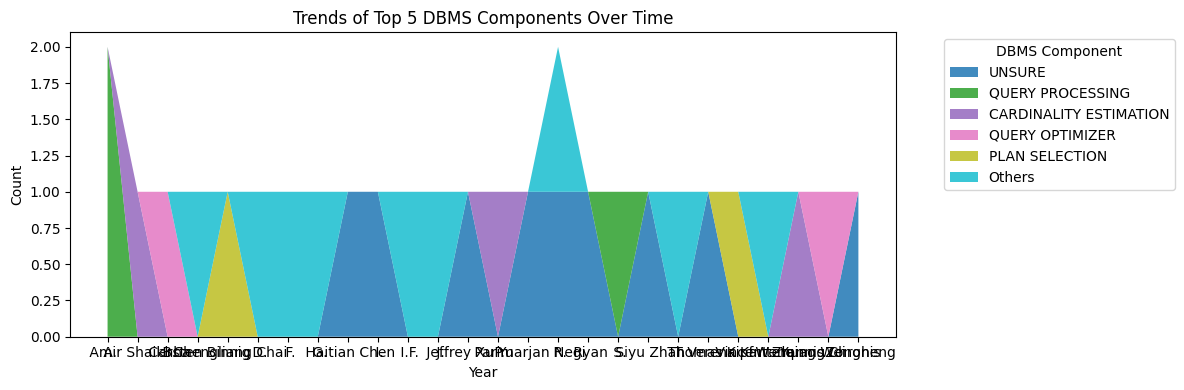

In [15]:
import numpy as np
import matplotlib.pyplot as plt

TOP_N = 5   # choose how many top components to show

target_cols = [col for col in answers_df_encoded.columns if col.startswith('DBMS Component_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby('Year').sum().sort_values('Year')

# Remove prefix for readability
time_series.rename(columns=lambda x: x.replace("DBMS Component_", ""), inplace=True)

total_counts = time_series.sum().sort_values(ascending=False)

top_components = total_counts.head(TOP_N).index
others = total_counts.index.difference(top_components)

# Build reduced dataframe
ts_reduced = time_series[top_components].copy()
ts_reduced["Others"] = time_series[others].sum(axis=1)


years = ts_reduced.index.values
stack_data = [ts_reduced[col].values for col in ts_reduced.columns]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(ts_reduced.columns))]

# PLOT
plt.figure(figsize=(12, 4))
plt.stackplot(years, stack_data, labels=ts_reduced.columns, colors=colors, alpha=0.85)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title(f"Trends of Top {TOP_N} DBMS Components Over Time")

plt.legend(title="DBMS Component", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Bar Plot of DBMS Components Targeted

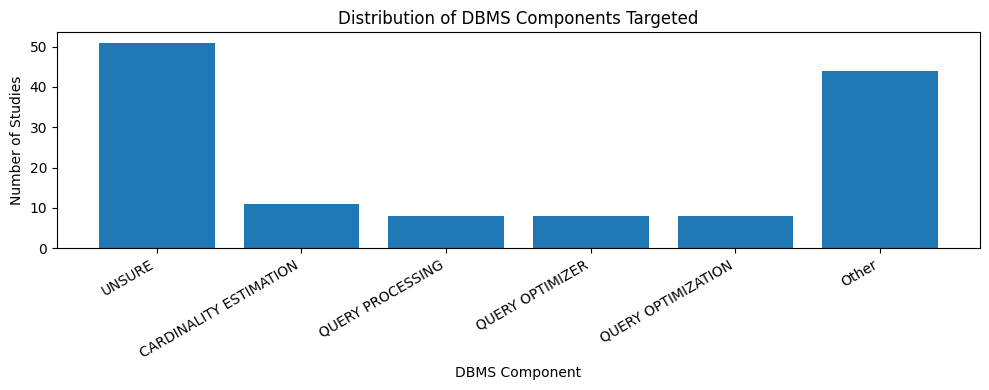

In [16]:
plot_multilabel_distribution(answers_df_encoded, "DBMS Component", "Distribution of DBMS Components Targeted", min_count=5)

### DBMS Components Targeted vs Type of Evaluation

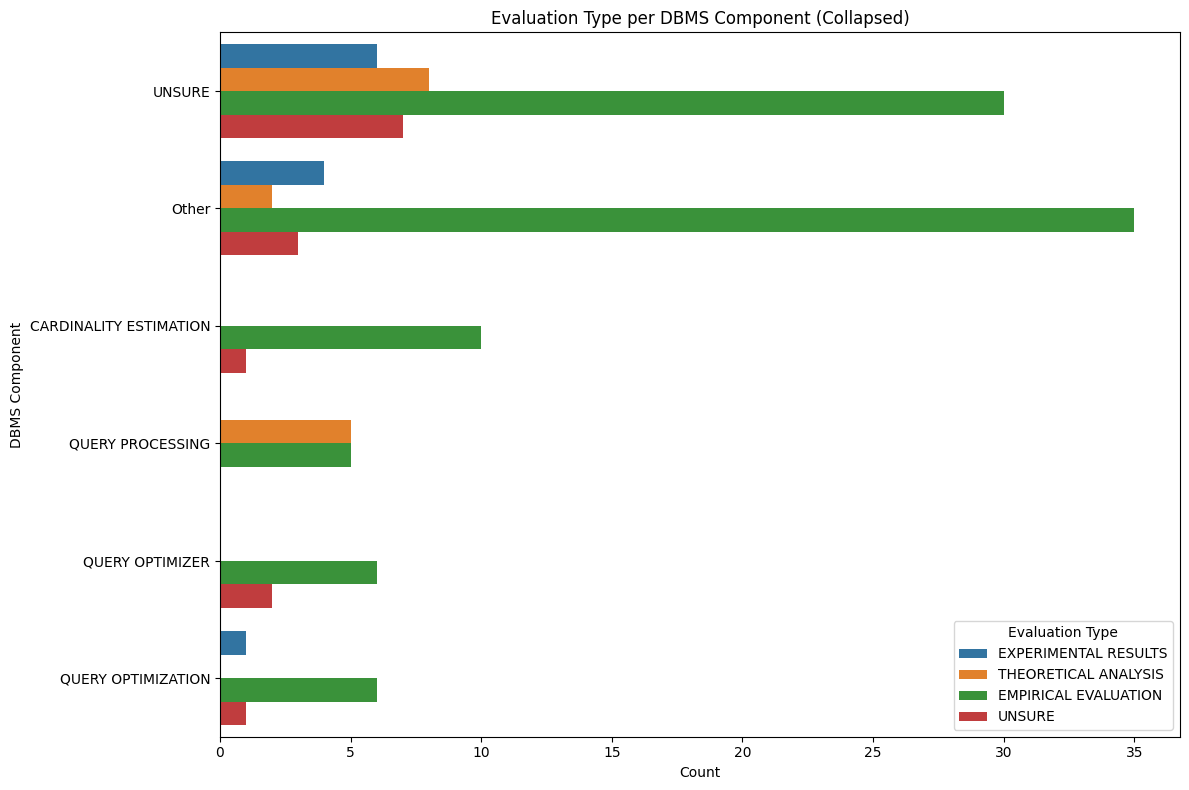

In [17]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Evaluation Type"
# )

plot_multilabel_relation_explode(answers_df, "DBMS Component", "Evaluation Type", min_count=5, figsize=(12,8))

### DBMS Components Targeted vs Technique Proposed

In [18]:
def group_rare_labels(df, col_name, min_count=2):
    """
    Replaces categories in a column (list or string) with 'Other'
    if they appear fewer than min_count times.
    """
    # Create a temporary copy to count frequencies
    temp_df = df.copy()

    # Ensure all values are lists for uniform counting
    temp_df[col_name] = temp_df[col_name].apply(lambda x: x if isinstance(x, list) else [x] if pd.notnull(x) else [])

    # Count frequency of each unique label
    exploded = temp_df[col_name].explode()
    label_counts = exploded.value_counts()

    # Identify labels that appear fewer than min_count times (e.g., 0 or 1)
    rare_labels = label_counts[label_counts < min_count].index

    # Define replacement logic
    def replace_rare(value):
        if isinstance(value, list):
            # Replace rare items in the list with 'Other'
            new_list = ["Other" if x in rare_labels else x for x in value]
            # Optional: Remove duplicates if multiple items became 'Other'
            return list(set(new_list)) if "Other" in new_list else new_list
        else:
            return "Other" if value in rare_labels else value

    # Apply the replacement to the original column
    return df[col_name].apply(replace_rare)

# 2. Apply the fix to your target column (Technique Proposed)
# min_count=2 groups anything with 0 or 1 study into 'Other'
answers_df["Technique Proposed"] = group_rare_labels(answers_df, "Technique Proposed", min_count=1)

/tmp/ipython-input-1644932716.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


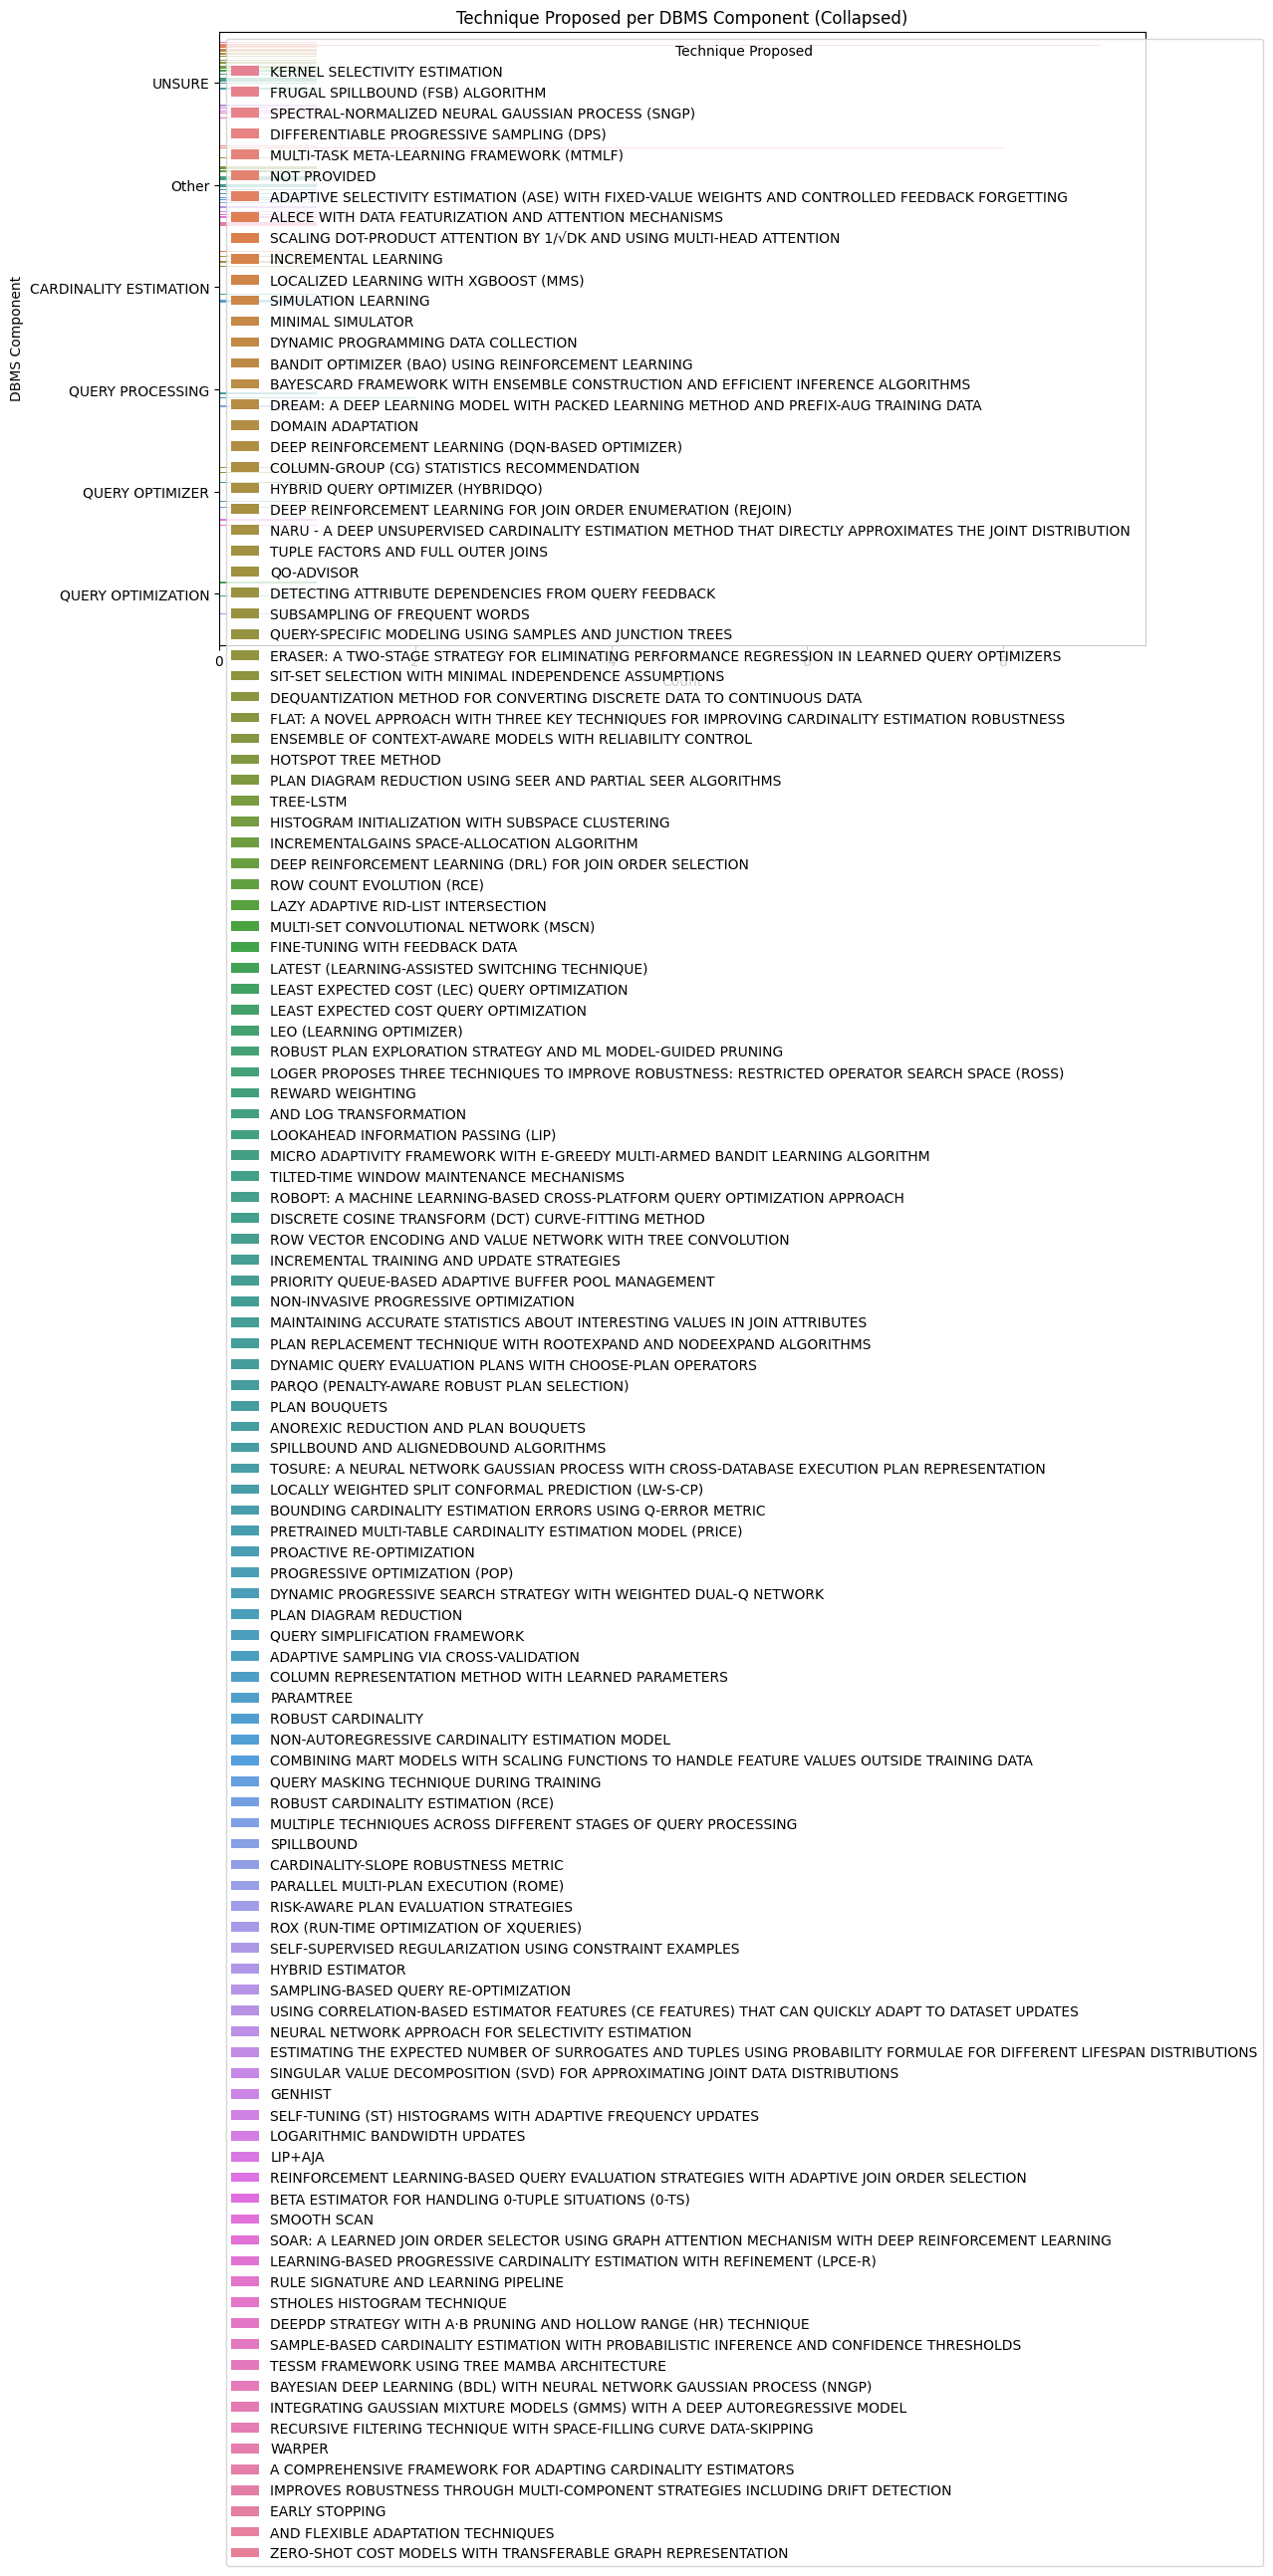

In [19]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Technique Proposed"
# )
plot_multilabel_relation_explode(answers_df, "DBMS Component", "Technique Proposed", min_count=8, figsize=(12,8))

### DBMS Components Targeted vs Metrics Used

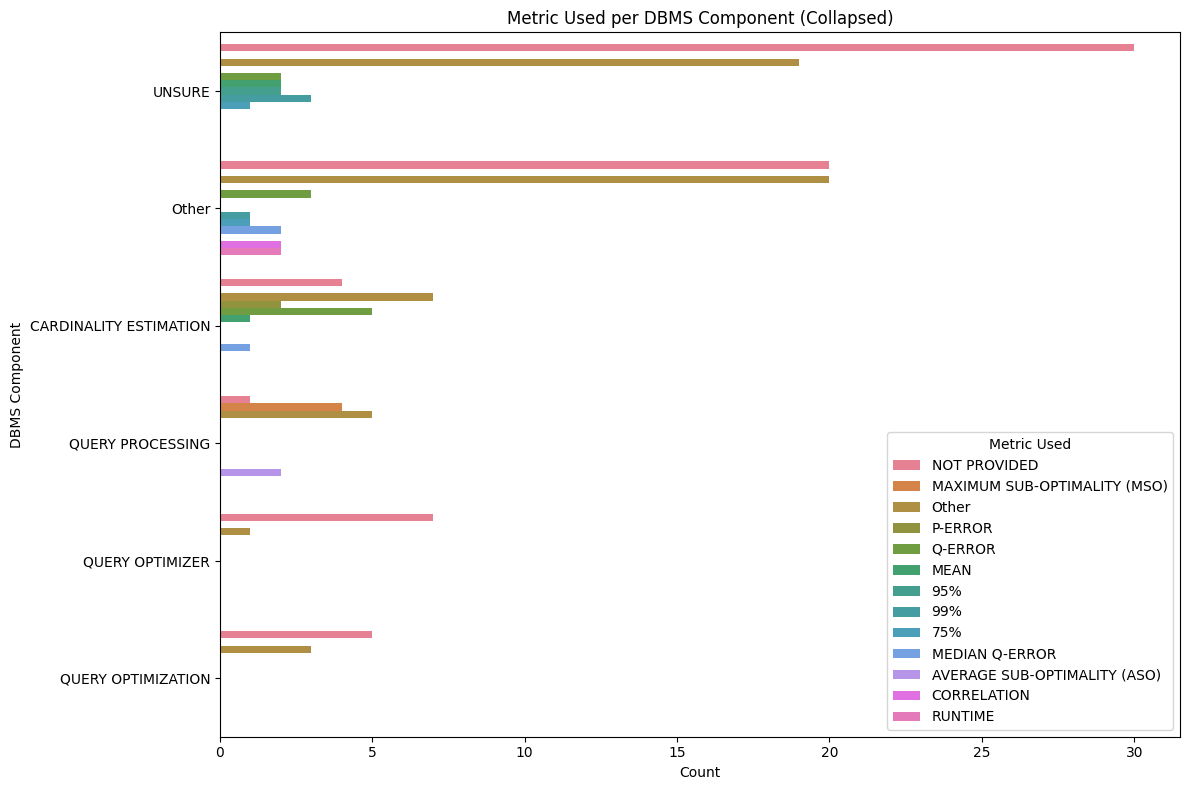

In [20]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Metric Used"
# )
garbage_labels = ['0', '1', '0.0', '1.0']

def clean_garbage(value):
    if isinstance(value, list):
        # Replace garbage in lists with 'Other'
        return ["Other" if str(x).strip() in garbage_labels else x for x in value]
    else:
        # Replace single garbage strings
        return "Other" if str(value).strip() in garbage_labels else value

answers_df["Metric Used"] = answers_df["Metric Used"].apply(clean_garbage)

# This groups actual valid labels that appear only once (count < 2)
answers_df["Metric Used"] = group_rare_labels(answers_df, "Metric Used", min_count=2)

# 3. Plot
plot_multilabel_relation_explode(answers_df, "DBMS Component", "Metric Used", min_count=8, figsize=(12,8))

### DBMS Components Targeted vs Benchmarks Used

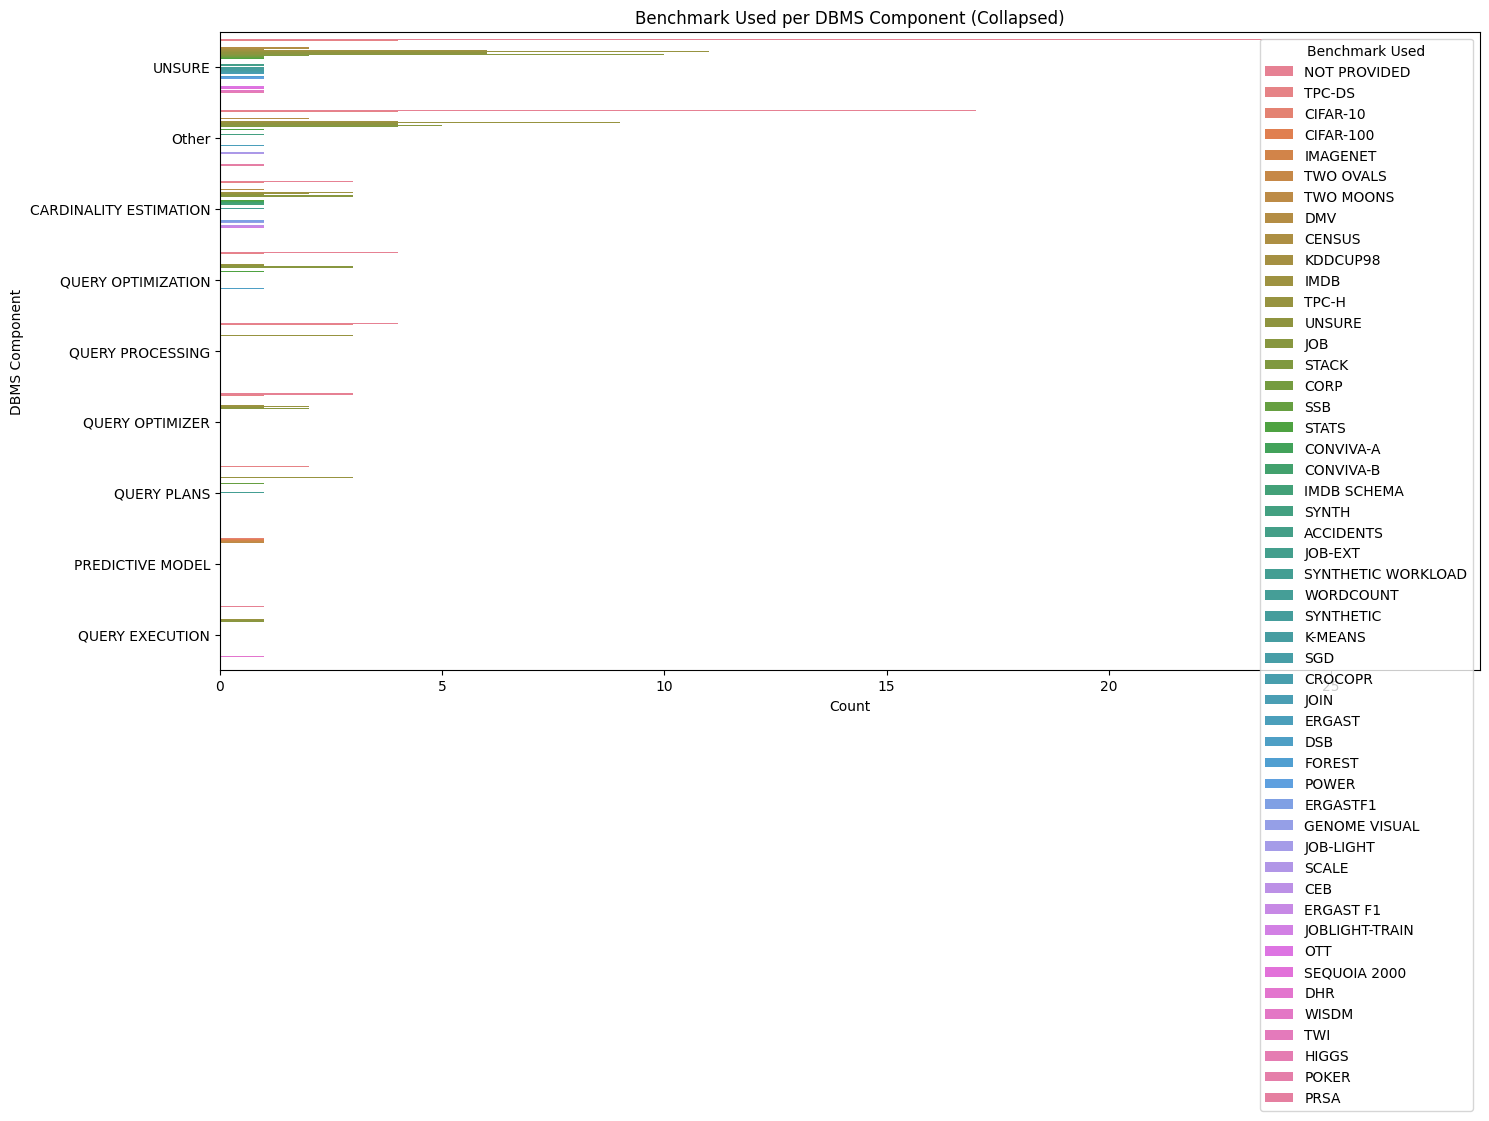

In [21]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Benchmark Used"
# )
def clean_benchmark_column(df, col_name):
    # Garbage strings to always remove
    garbage = ['0', '1', '0.0', '1.0', 'True', 'False']

    # Helper to clean a single cell (list or string)
    def clean_cell(value):
        if isinstance(value, list):
            return ["Other" if str(x).strip() in garbage else x for x in value]
        return "Other" if str(value).strip() in garbage else value

    # Apply garbage cleaning
    df[col_name] = df[col_name].apply(clean_cell)

    # Now group rare items (appearing only once) into 'Other'

    return group_rare_labels(df, col_name, min_count=1)


answers_df["Benchmark Used"] = clean_benchmark_column(answers_df, "Benchmark Used")
plot_multilabel_relation_explode(answers_df, "DBMS Component", "Benchmark Used", min_count=5, figsize=(15,10))

### DBMS Component Targeted vs Controlled Features

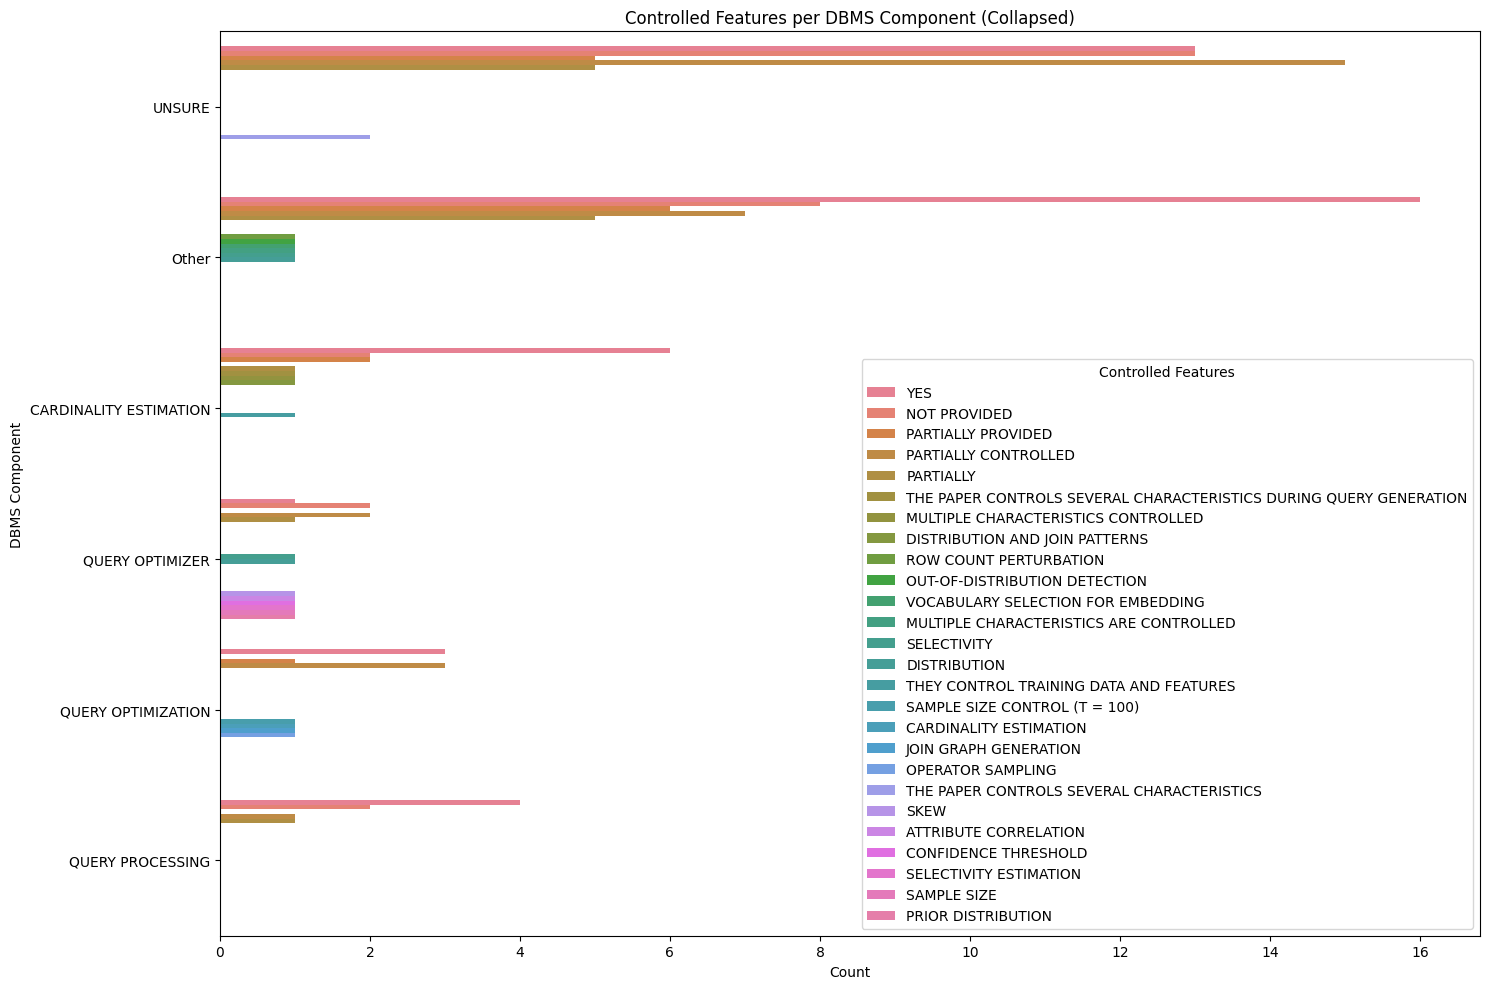

In [22]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Controlled Features"
# )
plot_multilabel_relation_explode(answers_df, "DBMS Component", "Controlled Features", min_count=5, figsize=(15,10))

### DBMS Component Targeted per Machine Learning Task Type

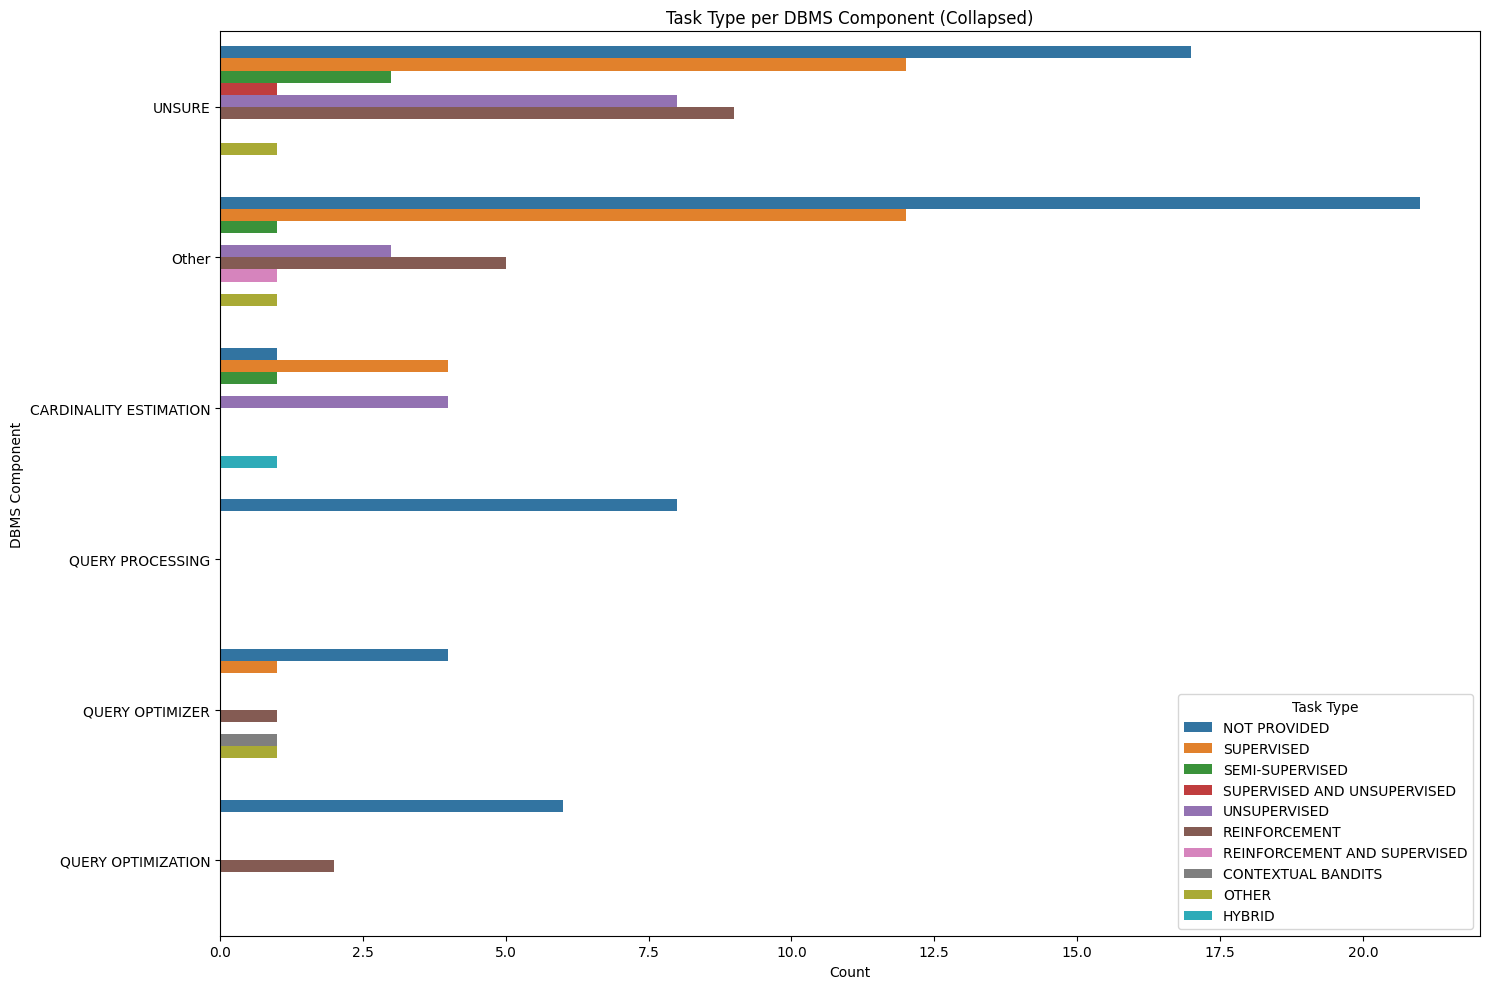

In [23]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Task Type"
# )
plot_multilabel_relation_explode(answers_df, "DBMS Component", "Task Type", min_count=5, figsize=(15,10))

### Machine Learning Paradigm Used per DBMS Component Targeted

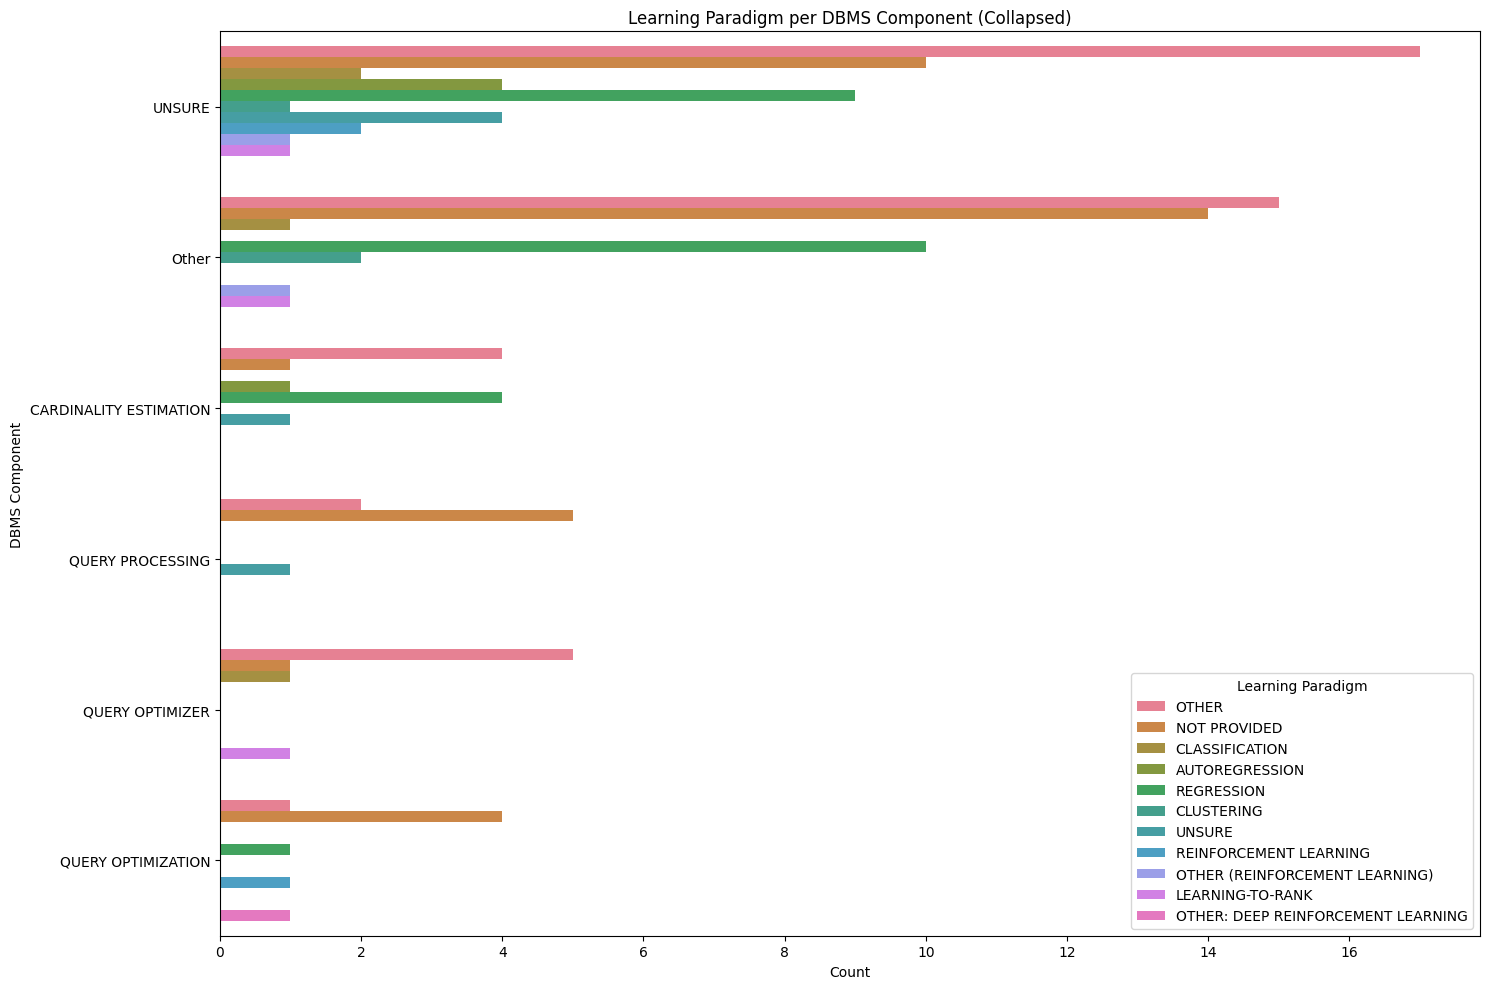

In [24]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Learning Paradigm"
# )
plot_multilabel_relation_explode(answers_df, "DBMS Component", "Learning Paradigm", min_count=5, figsize=(15,10))

### Input Encoding Methods per DBMS Component

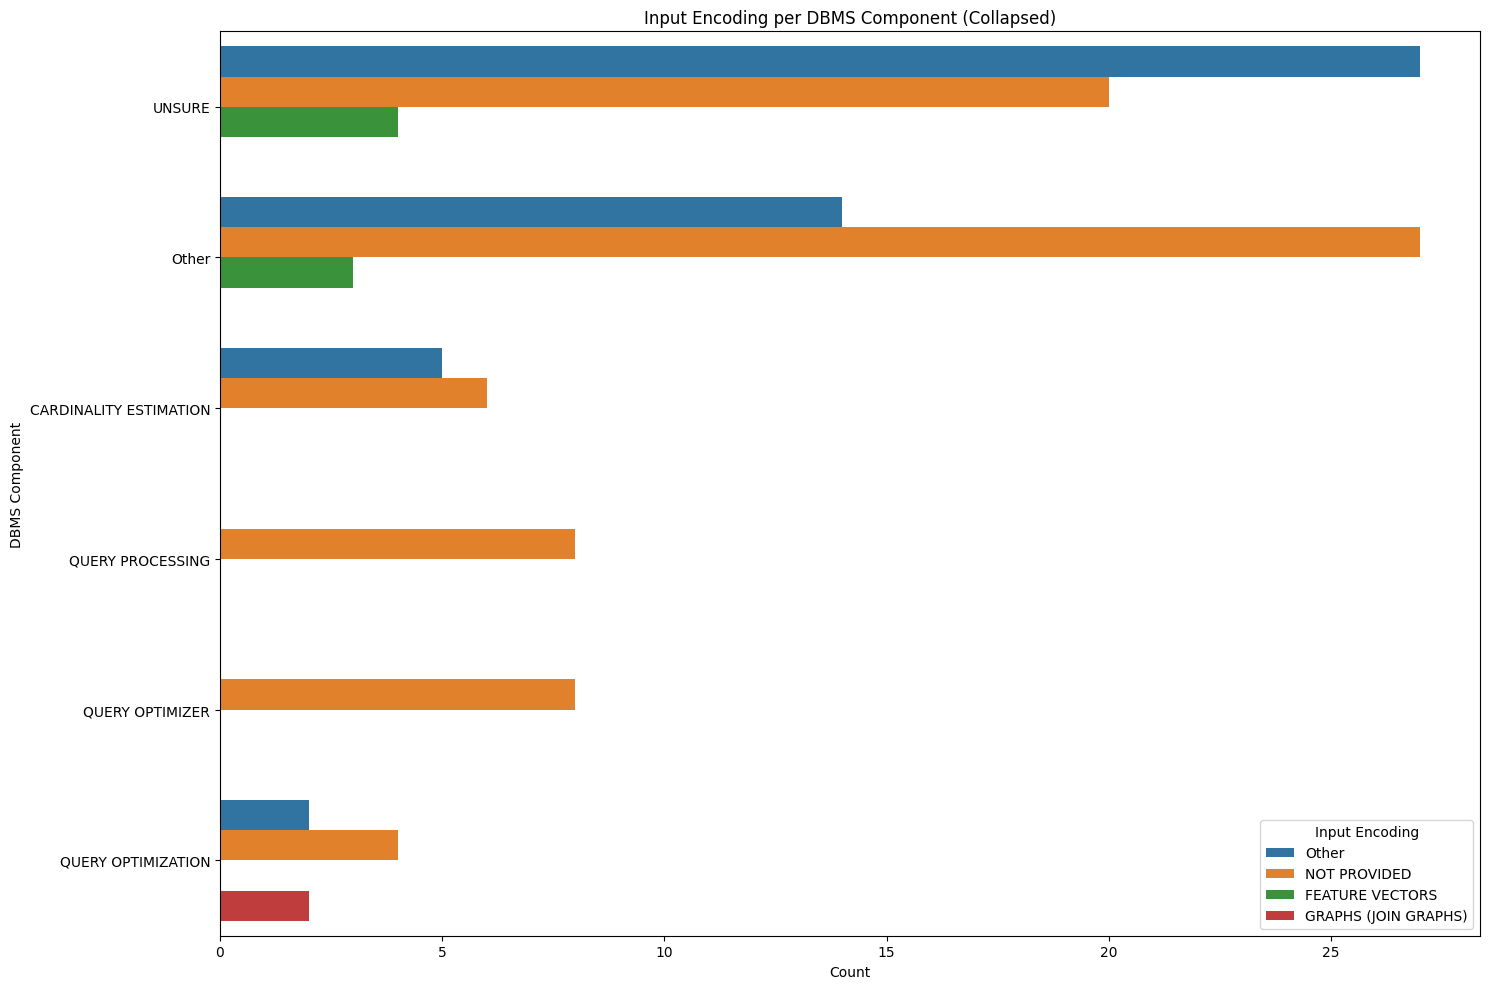

In [25]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Input Encoding"
# )
garbage_labels = ['0', '1', '0.0', '1.0', 'True', 'False']
answers_df["Input Encoding"] = answers_df["Input Encoding"].apply(
    lambda val: ["Other" if str(x).strip() in garbage_labels else x for x in val]
    if isinstance(val, list) else
    ("Other" if str(val).strip() in garbage_labels else val)
)

#  group any encoding that appears only once into "Other"
answers_df["Input Encoding"] = group_rare_labels(answers_df, "Input Encoding", min_count=2)

#  Plot
plot_multilabel_relation_explode(
    answers_df,
    "DBMS Component",
    "Input Encoding",
    min_count=5,
    figsize=(15,10)
)

### DBMS Components Targeted vs Uncertainty Evaluation

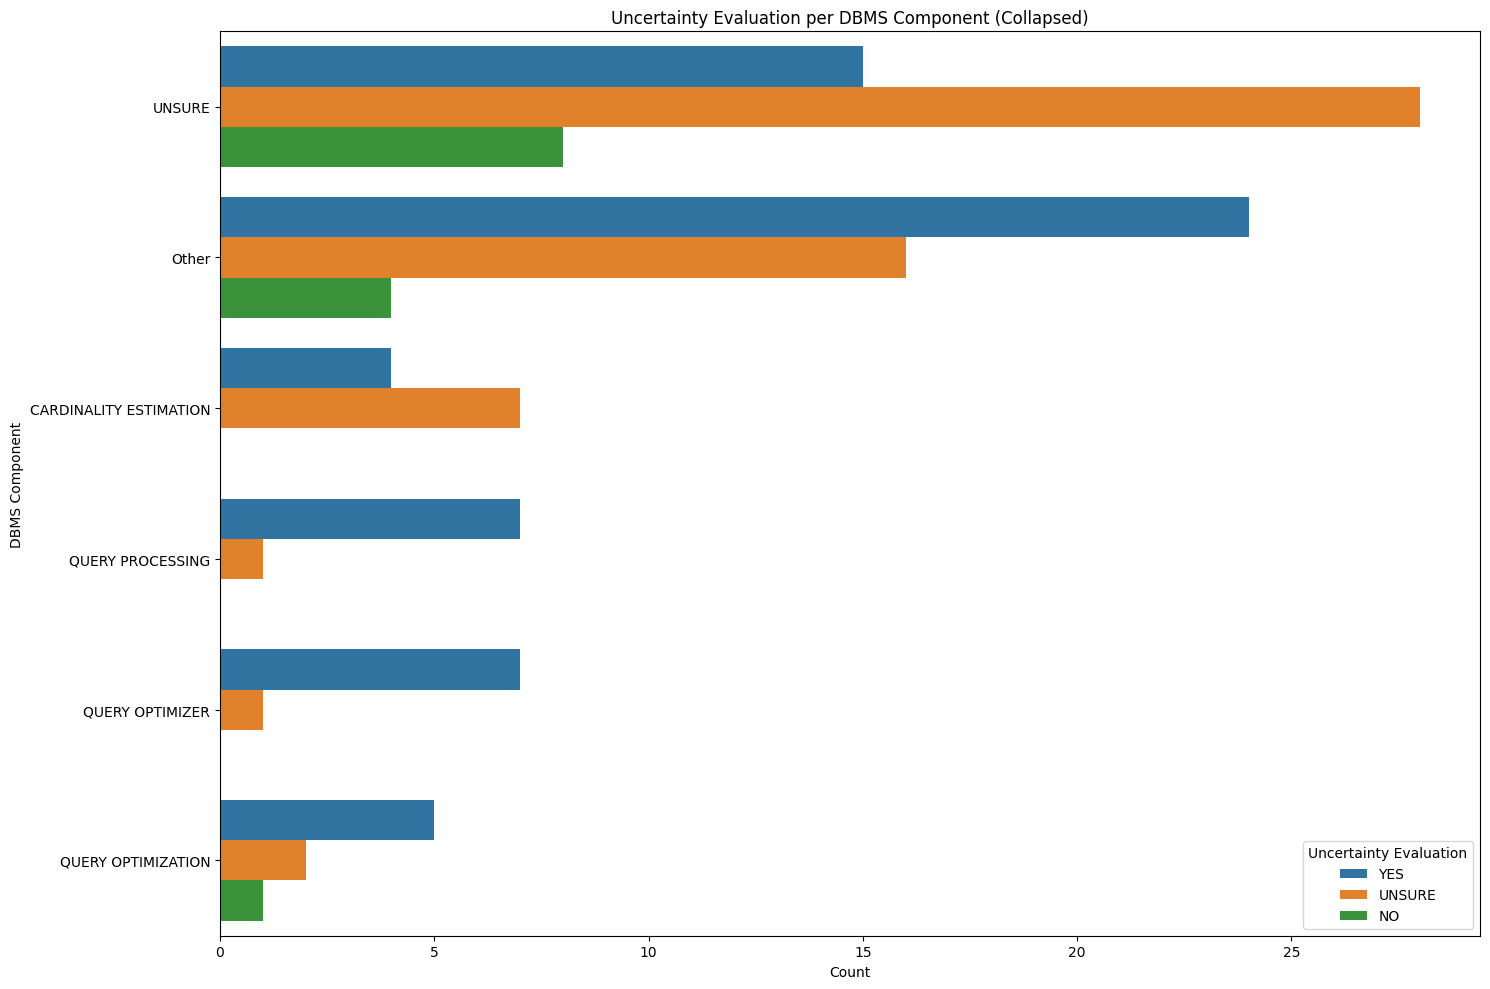

In [26]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Uncertainty Evaluation"
# )

plot_multilabel_relation_explode(
    answers_df,
    "DBMS Component",
    "Uncertainty Evaluation",
    min_count=5,
    figsize=(15,10)
)

### Architecture Used per DBMS Component

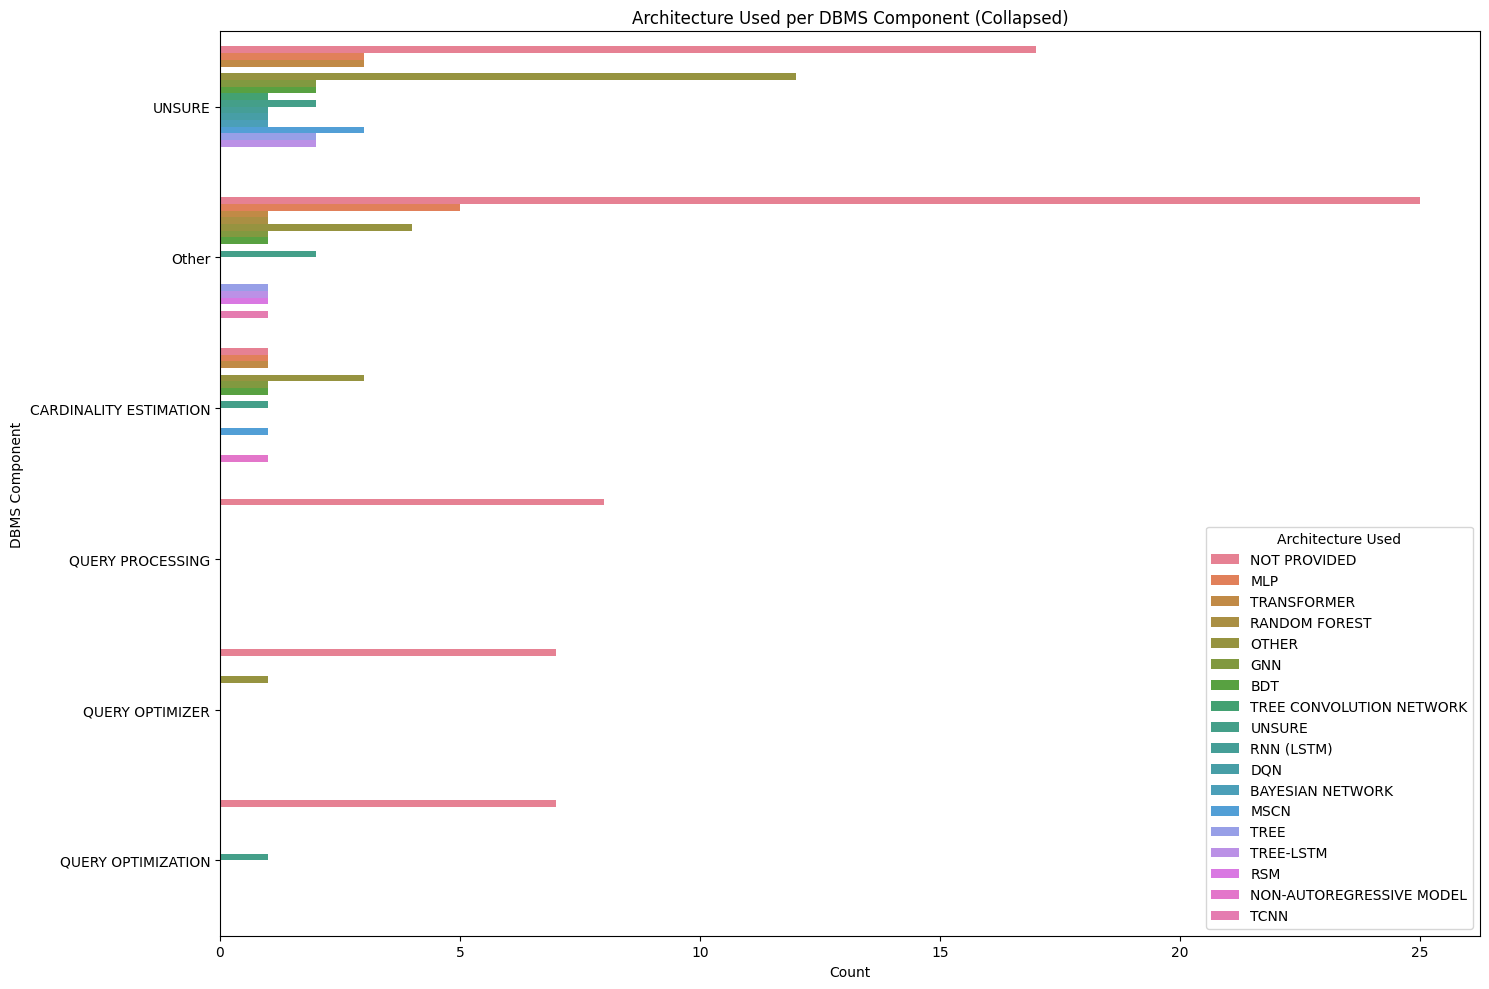

In [27]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="DBMS Component",
#     col_y="Architecture Used"
# )

plot_multilabel_relation_explode(
    answers_df,
    "DBMS Component",
   "Architecture Used",
    min_count=5,
    figsize=(15,10)
)

## Analysis on the Types of Evaluation

### Types of Evaluation Done Over Time

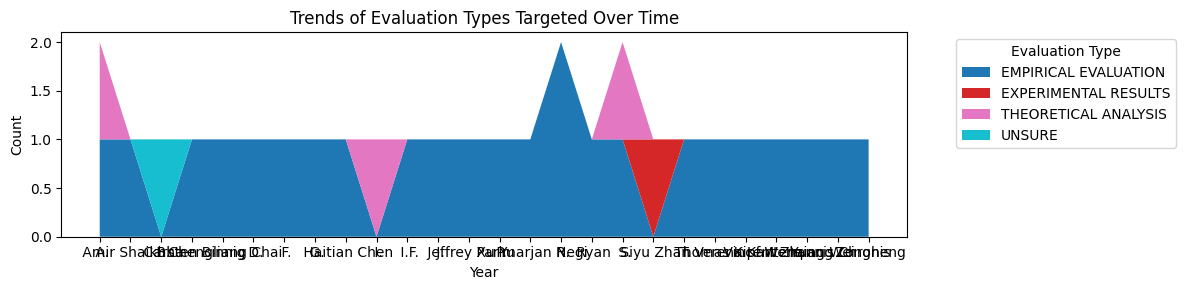

In [28]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Evaluation Type_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Evaluation Type_', '') if x.startswith('Evaluation Type_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Evaluation Types Targeted Over Time")
plt.legend(title="Evaluation Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Evaluation Type

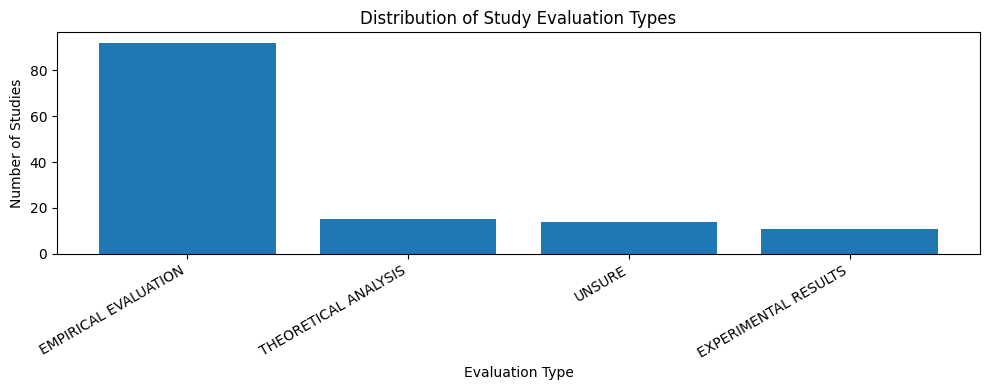

In [29]:
plot_multilabel_distribution(answers_df_encoded, "Evaluation Type", "Distribution of Study Evaluation Types")

## Analysis of Benchmarks Used

### Benchmarks Used Over Time

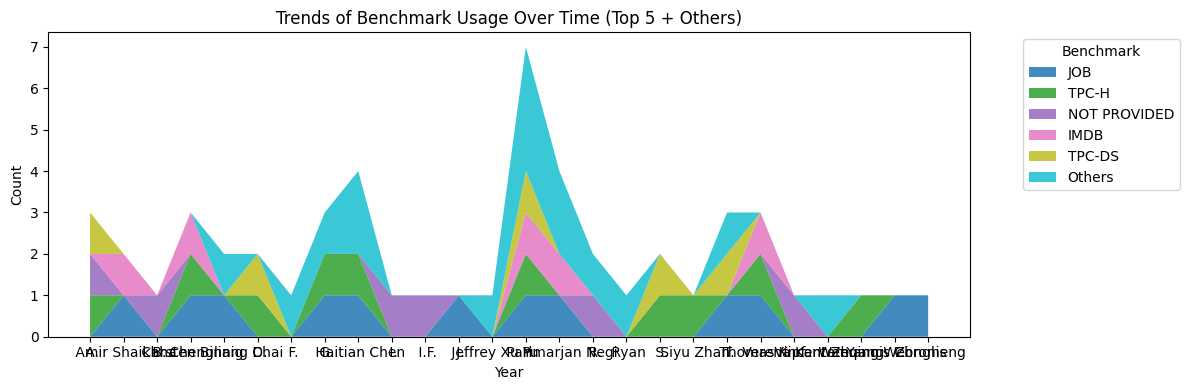

In [30]:
TOP_N = 5   # choose how many benchmarks to show


target_cols = [col for col in answers_df_encoded.columns if col.startswith('Benchmark Used_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby('Year').sum().sort_values('Year')

# Remove prefix for readability
time_series.rename(
    columns=lambda x: x.replace('Benchmark Used_', '') if x.startswith('Benchmark Used_') else x,
    inplace=True
)


total_counts = time_series.sum().sort_values(ascending=False)

top_benchmarks = total_counts.head(TOP_N).index
others = total_counts.index.difference(top_benchmarks)

# Build reduced dataframe
ts_reduced = time_series[top_benchmarks].copy()
ts_reduced["Others"] = time_series[others].sum(axis=1)


years = ts_reduced.index.values
stack_data = [ts_reduced[col].values for col in ts_reduced.columns]


cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(ts_reduced.columns))]

# PLOT
plt.figure(figsize=(12, 4))
plt.stackplot(years, stack_data, labels=ts_reduced.columns, colors=colors, alpha=0.85)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title(f"Trends of Benchmark Usage Over Time (Top {TOP_N} + Others)")

plt.legend(title="Benchmark", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# old

In [31]:
# target_cols = [col for col in answers_df_encoded.columns if col.startswith('Benchmark Used_')]

# time_series = answers_df_encoded[['Year'] + target_cols].copy()
# time_series = time_series.groupby(by='Year').sum()
# time_series.sort_values(by='Year', inplace=True)

# time_series.rename(
#     columns=lambda x: x.replace('Benchmark Used_', '') if x.startswith('Benchmark Used_') else x,
#     inplace=True
# )

# # Prepare the data for the stackplot
# years = time_series.index.values
# stack_data = [time_series[col].values for col in time_series.columns]

# # Generate a pastel color palette using the 'tab10' colormap
# cmap = plt.get_cmap("tab10")
# colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

# plt.figure(figsize=(12, 3))
# plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

# plt.xlabel("Year")
# plt.ylabel("Count")
# plt.title("Trends of Benchmarks Targeted Over Time")
# plt.legend(title="Benchmark", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

### Bar Plot of Benchmarks Used

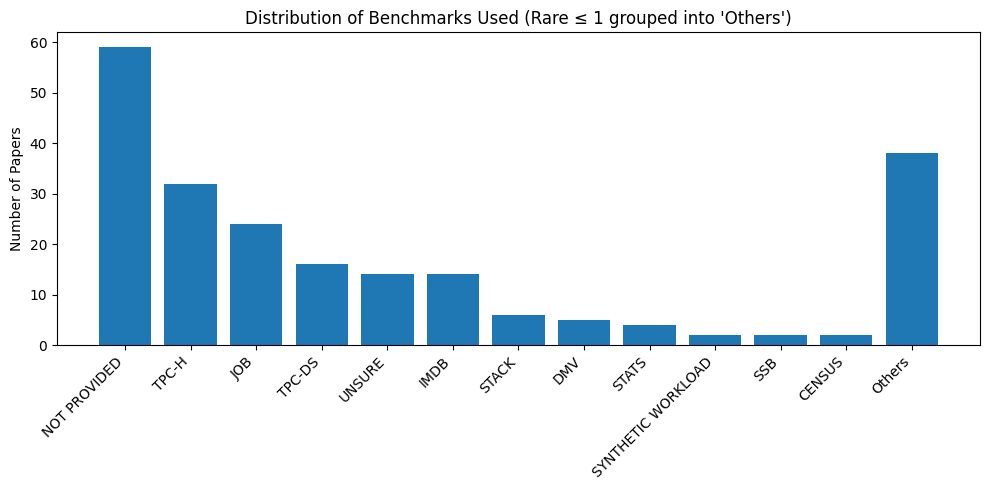

In [32]:
def plot_benchmark_distribution_with_others(
    df,
    prefix="Benchmark Used",
    title="Distribution of Benchmarks Used",
    min_count=2      # collapse benchmarks that appear <= this number
):
    # Select columns with this prefix
    cols = [col for col in df.columns if col.startswith(prefix + "_")]
    if not cols:
        print("No benchmark columns found.")
        return

    # Frequency of each benchmark
    freq = df[cols].sum().sort_values(ascending=False)

    # Separate frequent and rare benchmarks
    frequent = freq[freq > min_count]
    rare = freq[freq <= min_count]

    # Add "Others" category combining rare ones
    if len(rare) > 0:
        frequent["Others"] = rare.sum()

    # Clean names
    frequent.index = frequent.index.str.replace(prefix + "_", "")

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(frequent.index, frequent.values)

    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Number of Papers")
    plt.title(f"{title} (Rare ≤ {min_count} grouped into 'Others')")
    plt.tight_layout()
    plt.show()


plot_benchmark_distribution_with_others(
    answers_df_encoded,
    prefix="Benchmark Used",
    title="Distribution of Benchmarks Used",
    min_count=1      # papers appearing once go to "Others"
)

In [33]:
# plot_multilabel_distribution(answers_df_encoded, "Benchmark Used", "Distribution of Benchmarks Used")

### Data Source per Benchmark

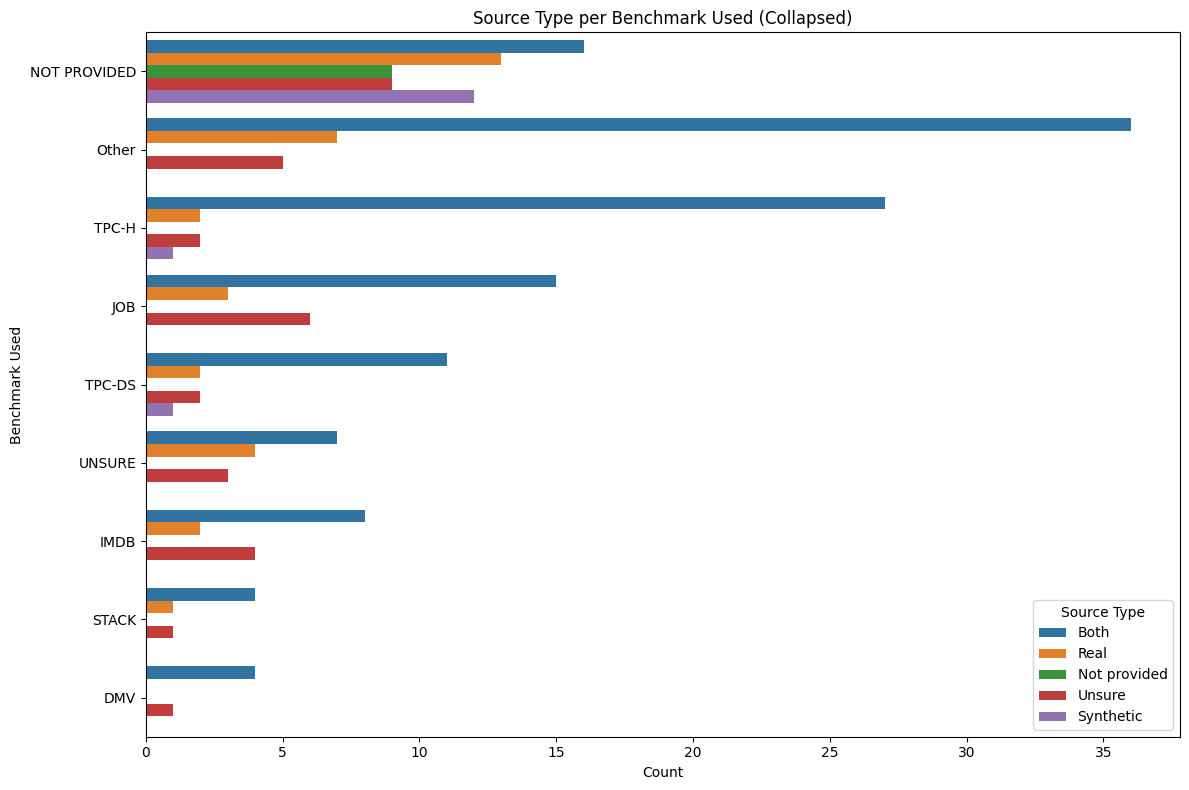

In [34]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Benchmark Used",
    col_y="Source Type"
)

### Machine Learning Task Types per Benchmark

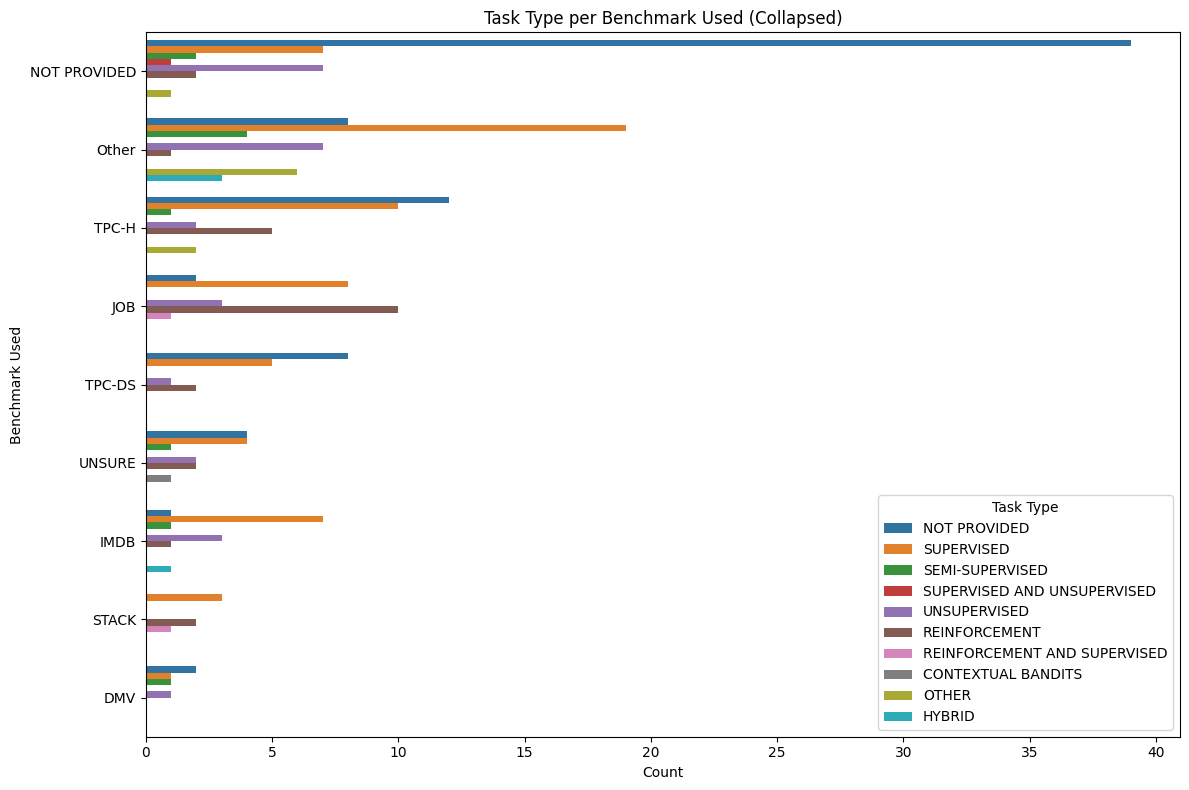

In [35]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Benchmark Used",
    col_y="Task Type"
)

### Machine Learning Paradigms per Benchmark

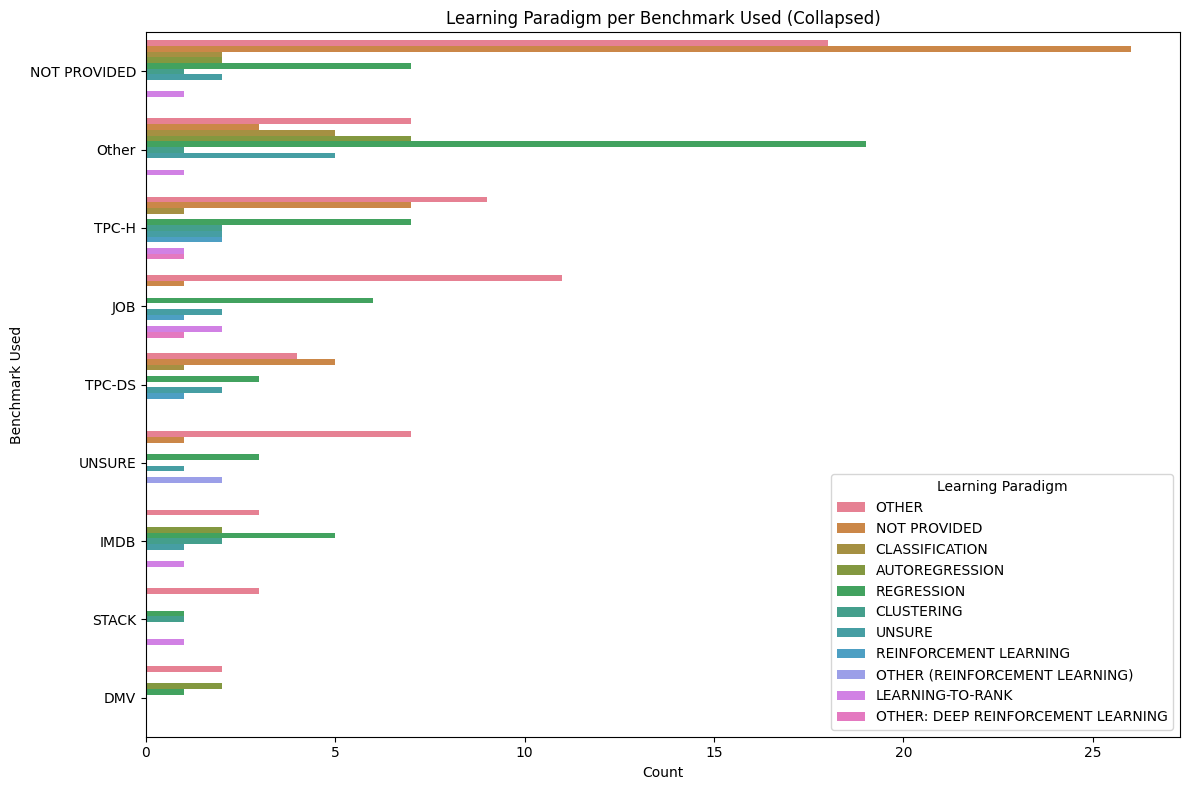

In [36]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Benchmark Used",
    col_y="Learning Paradigm"
)

### Benchmark vs Uncertainty Evaluation

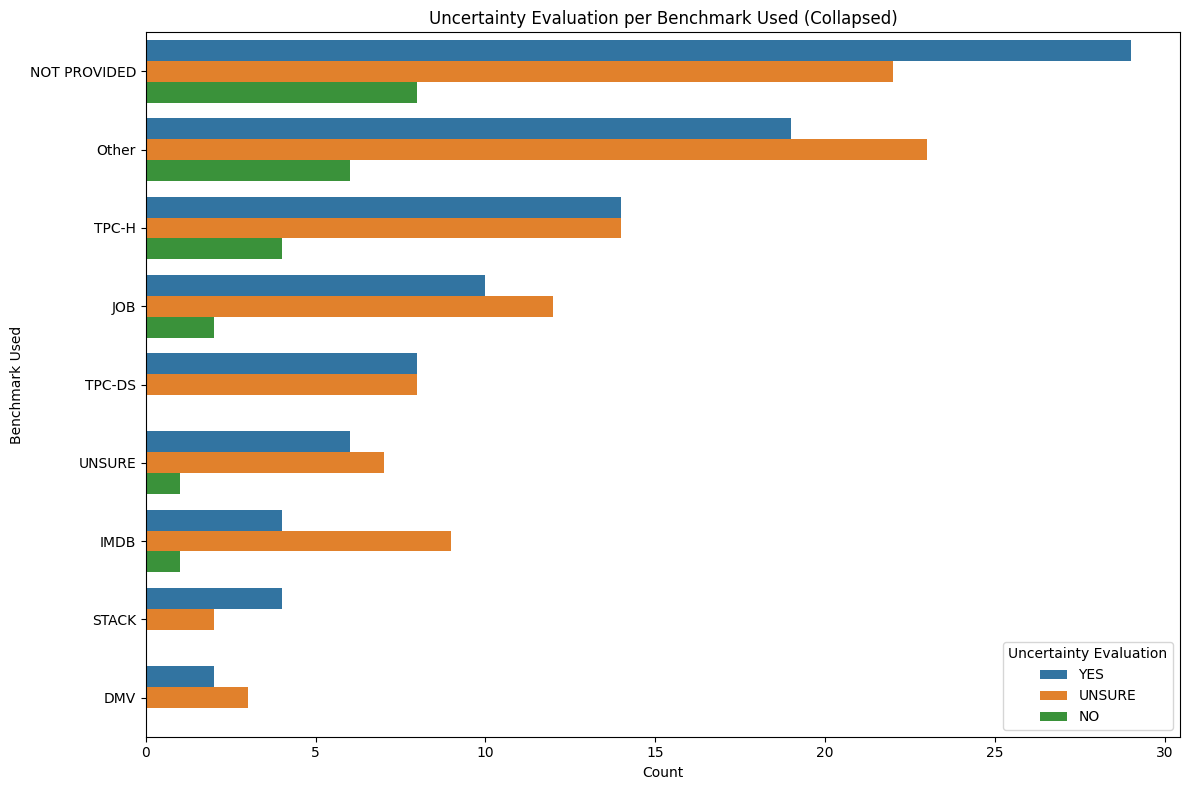

In [37]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Benchmark Used",
    col_y="Uncertainty Evaluation"
)

### Benchmark vs Out of Distribution Evaluation

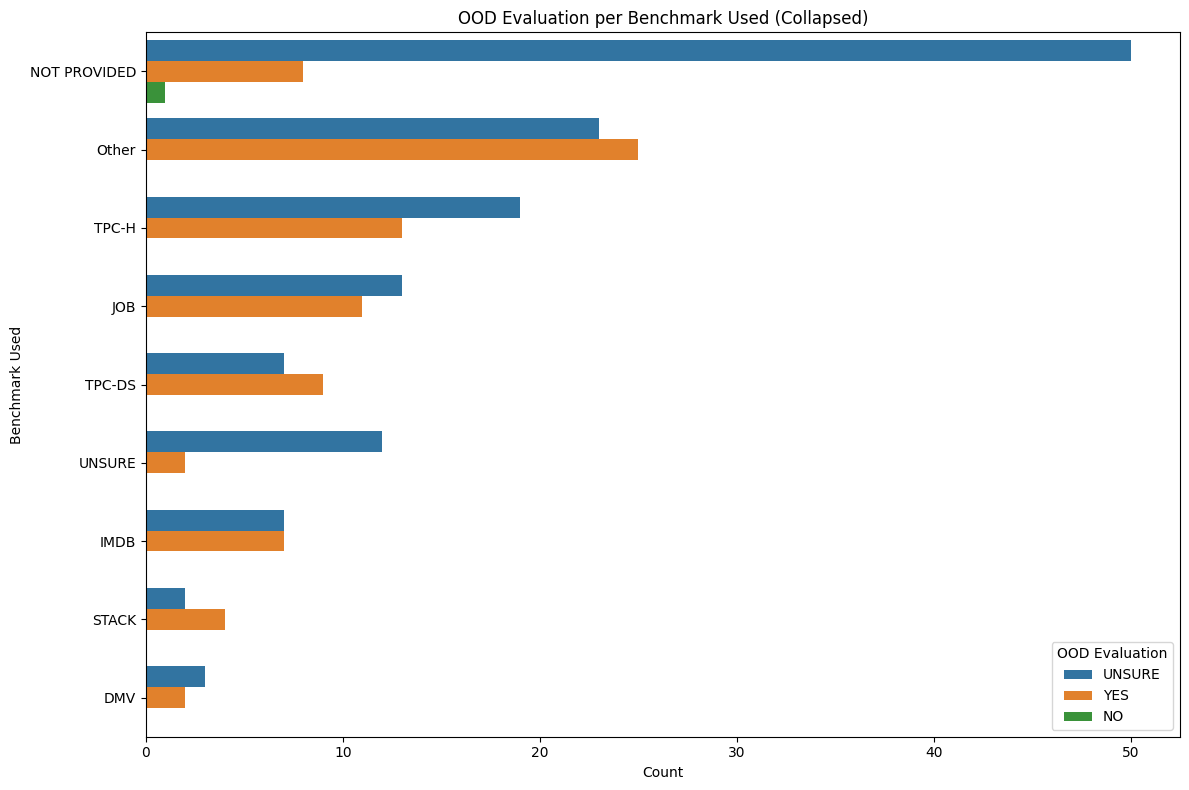

In [38]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Benchmark Used",
    col_y="OOD Evaluation"
)

## Analysis on Controlled Features

### Controlled Features During Training Over Time

/tmp/ipython-input-2594641673.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


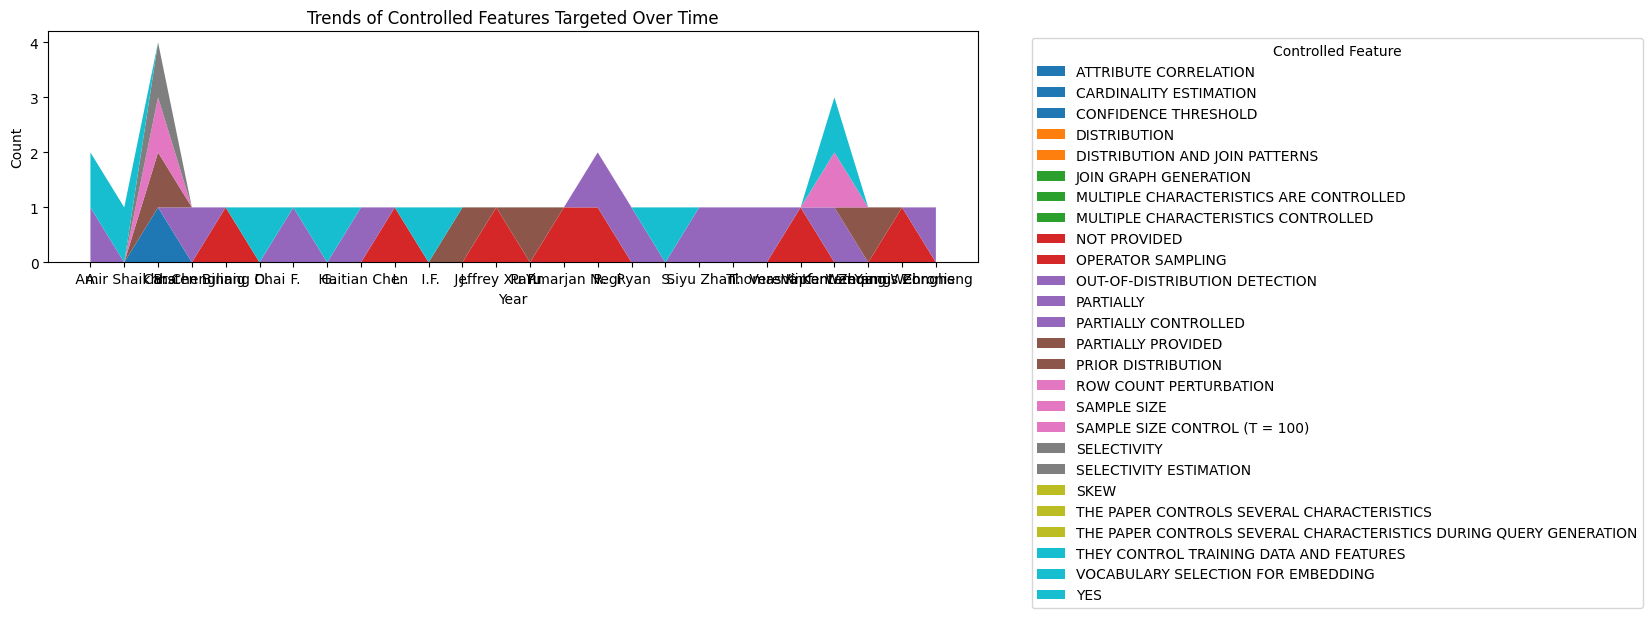

In [39]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Controlled Features_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Controlled Features_', '') if x.startswith('Controlled Features_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Controlled Features Targeted Over Time")
plt.legend(title="Controlled Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Features Controlled During Training

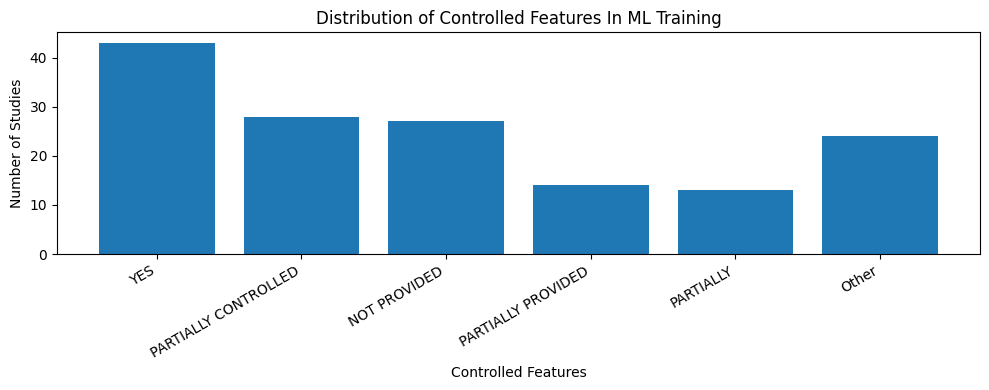

In [40]:
plot_multilabel_distribution(answers_df_encoded, "Controlled Features", "Distribution of Controlled Features In ML Training")

### Features Controlled During Training Per ML Task Type

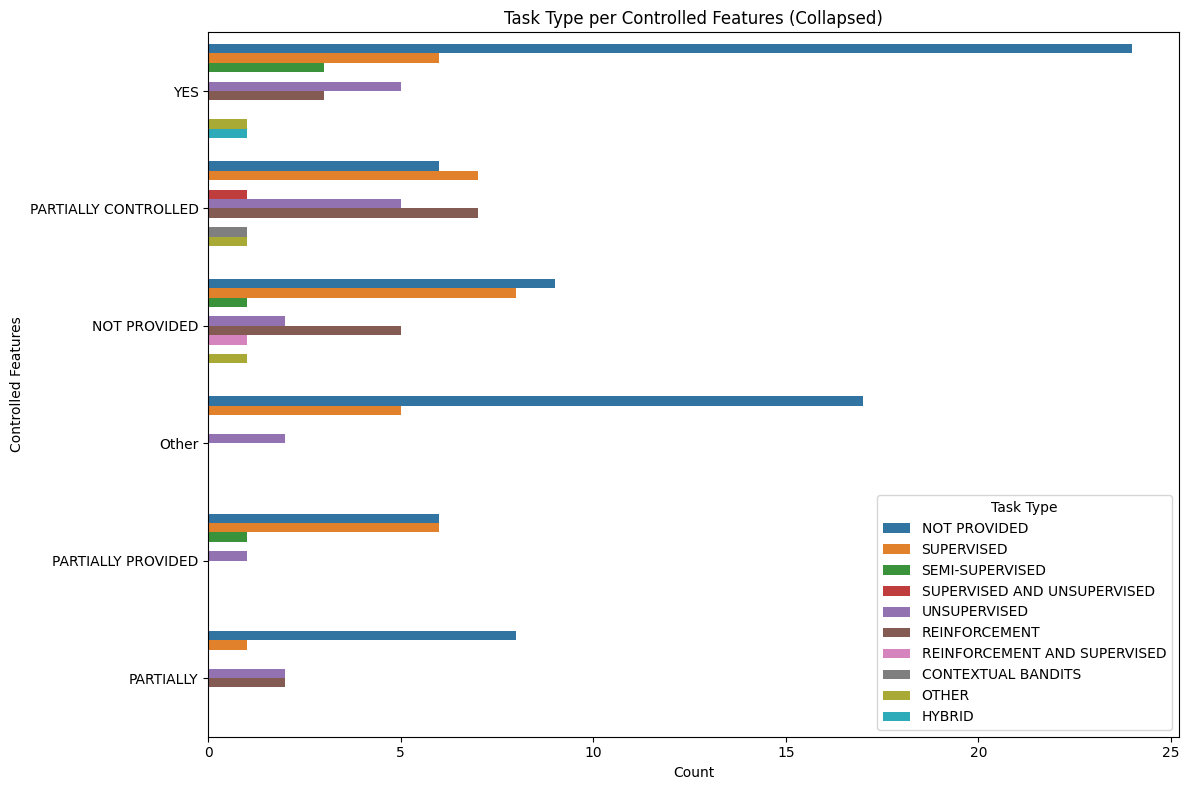

In [41]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Controlled Features",
    col_y="Task Type"
)

### Features Controlled During Training Per ML Task Type

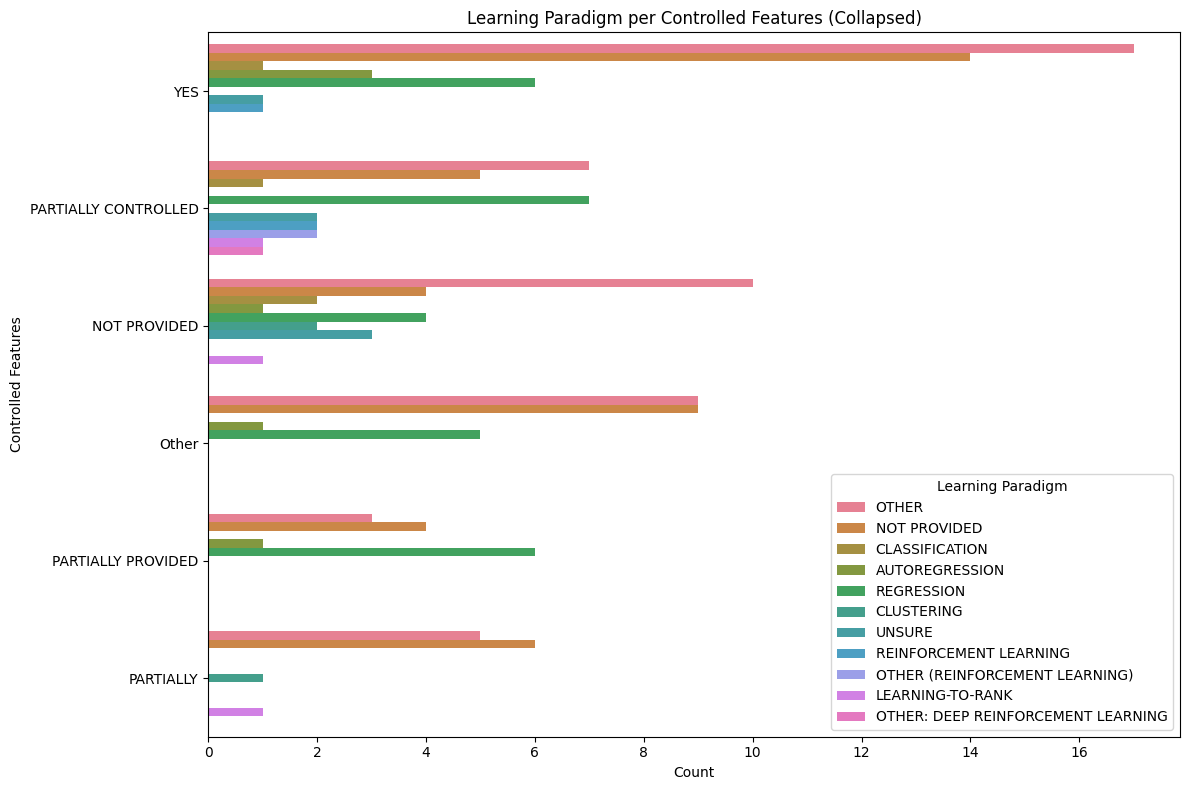

In [42]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Controlled Features",
    col_y="Learning Paradigm"
)

### Features Controlled per Model Architecture

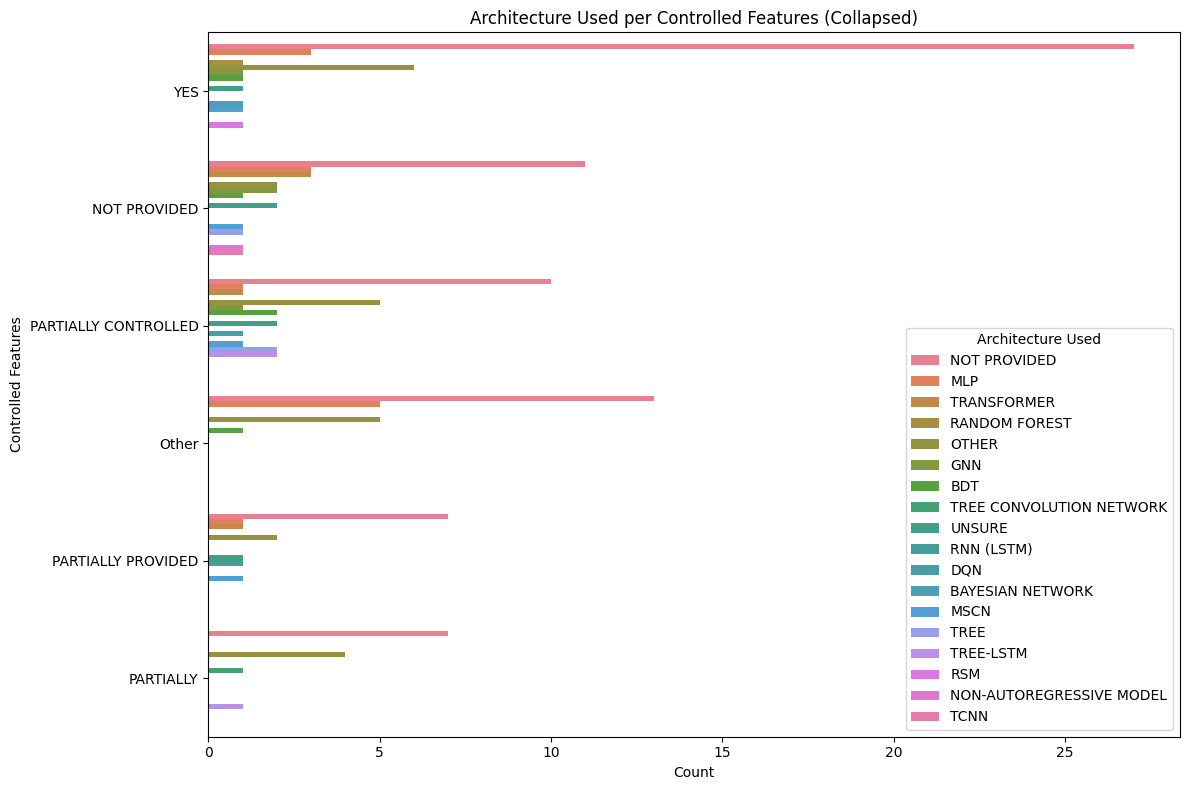

In [43]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Controlled Features",
    col_y="Architecture Used"
)

## Analysis on Machine Learning Task Type

### Distribution of Task Type Over all Papers Over Time

In [44]:
# stack_data.shape

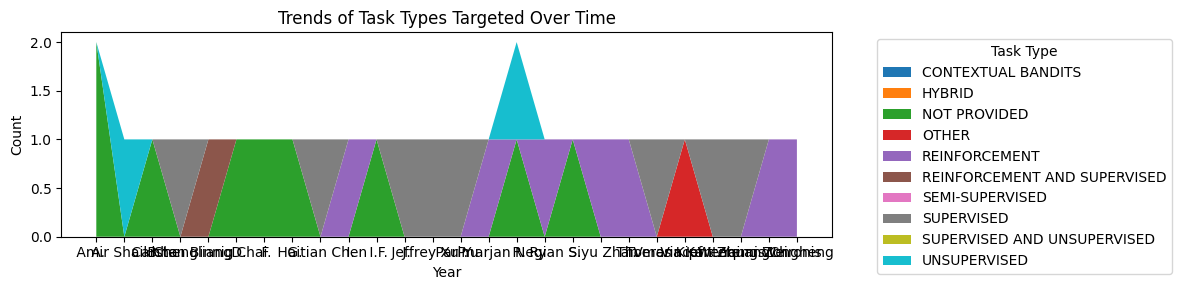

In [45]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Task Type_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Task Type_', '') if x.startswith('Task Type_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Task Types Targeted Over Time")
plt.legend(title="Task Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Task Type Over all Papers

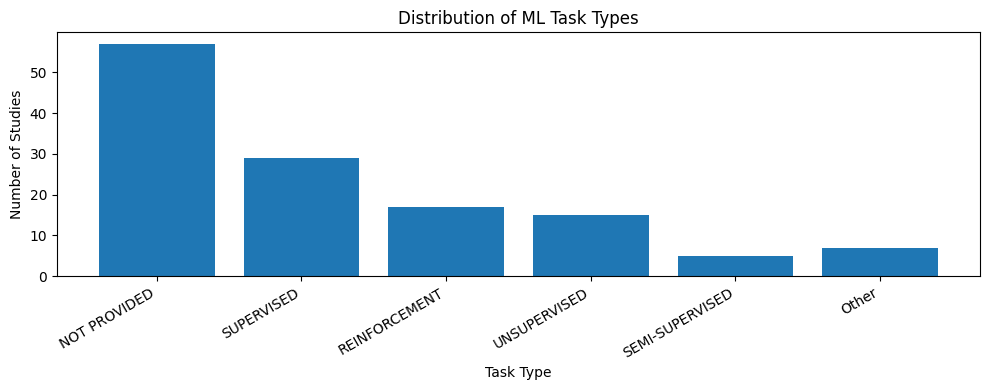

In [46]:
plot_multilabel_distribution(answers_df_encoded, "Task Type", "Distribution of ML Task Types")

### Comparing distribution of Learning Pardigm per Task Type

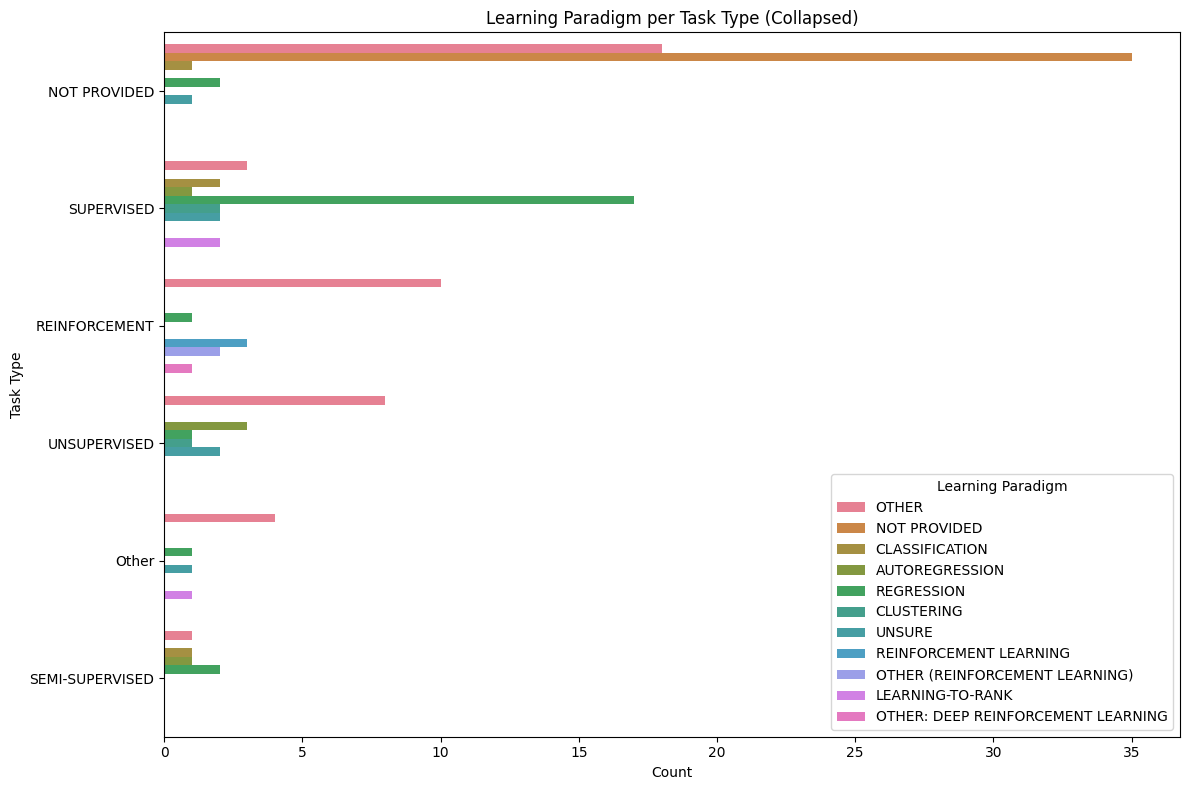

In [47]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Task Type",
    col_y="Learning Paradigm"
)

### Data Generation methods per Task Type

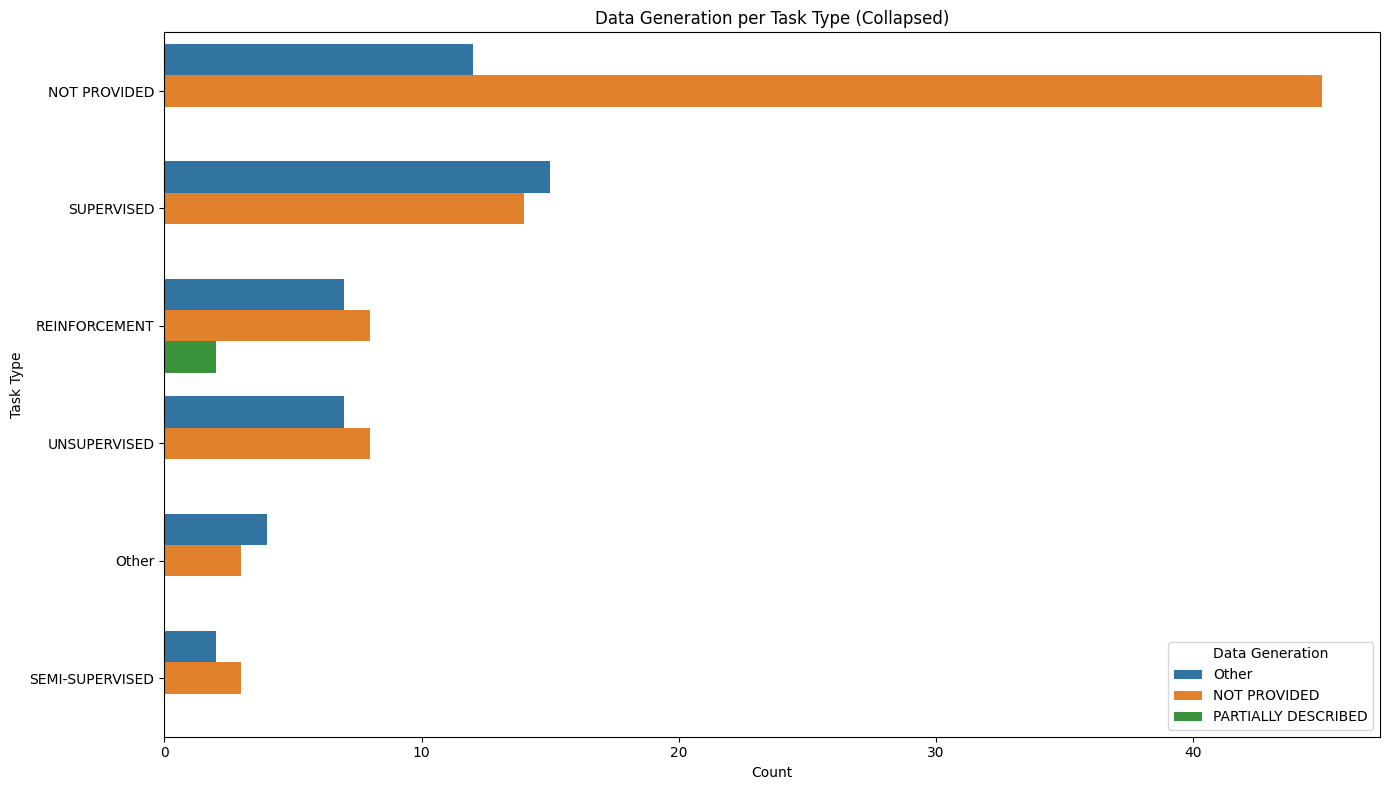

In [48]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="Task Type",
#     col_y="Data Generation"
# )

columns_to_fix = ["Task Type", "Data Generation"]
garbage = ['0', '1', '0.0', '1.0', 'True', 'False', 'nan', 'None']

for col in columns_to_fix:
    if col in answers_df.columns:
        # Remove Garbage
        answers_df[col] = answers_df[col].apply(
            lambda val: ["Other" if str(x).strip() in garbage else x for x in val]
            if isinstance(val, list) else
            ("Other" if str(val).strip() in garbage else val)
        )

        # Group rare items (appearing only once)
        answers_df[col] = group_rare_labels(answers_df, col, min_count=2)

plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Task Type",
    col_y="Data Generation",
    min_count=5,
    figsize=(14, 8)
)

### Distribution of Encoding Techniques per Task Type

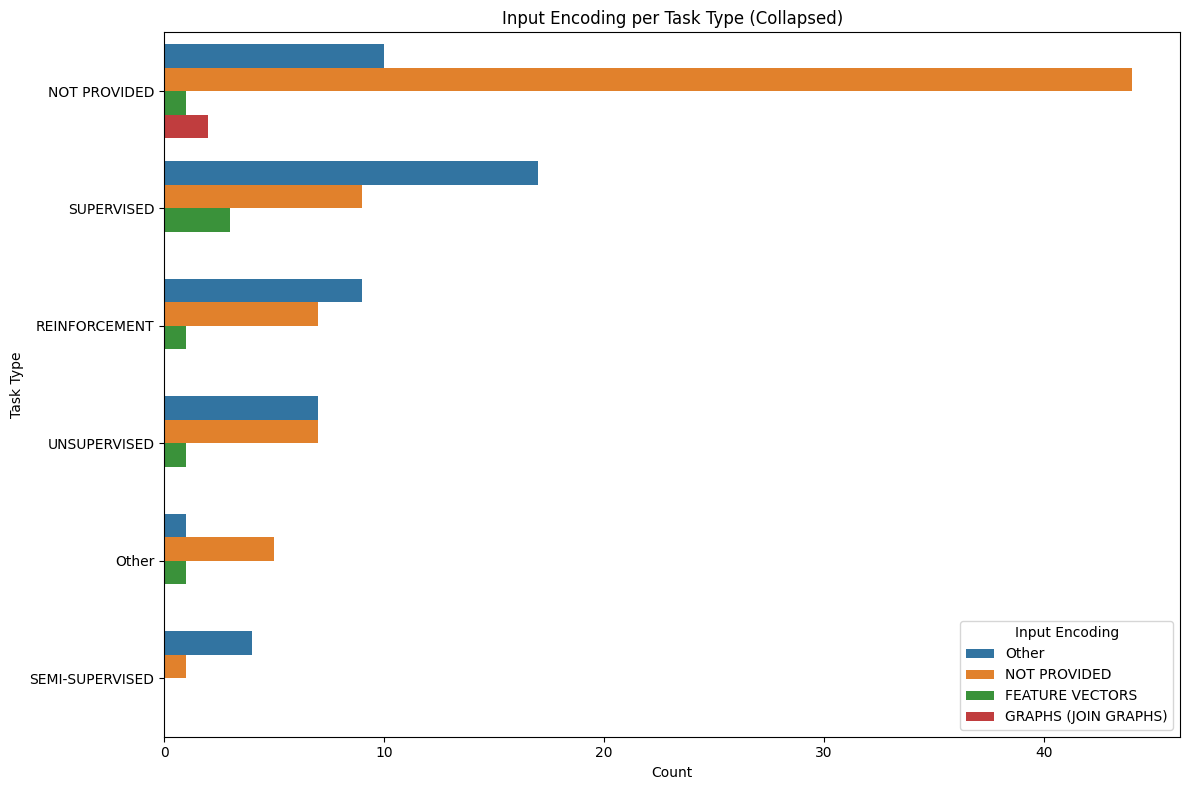

In [49]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Task Type",
    col_y="Input Encoding"
)

###  Uncertainty Evaluation Counts per Task Type

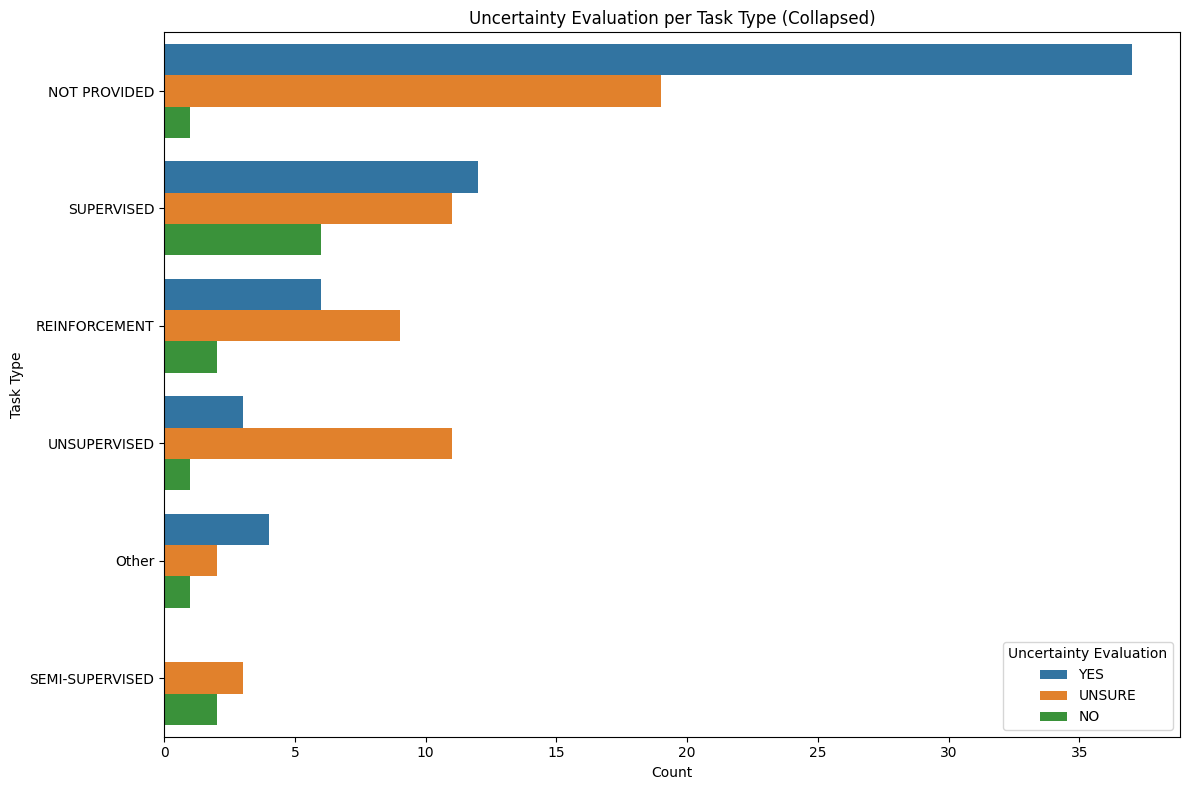

In [50]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Task Type",
    col_y="Uncertainty Evaluation"
)

### Distribution of Techniques that Evaluate Out of Distribution per Task Type

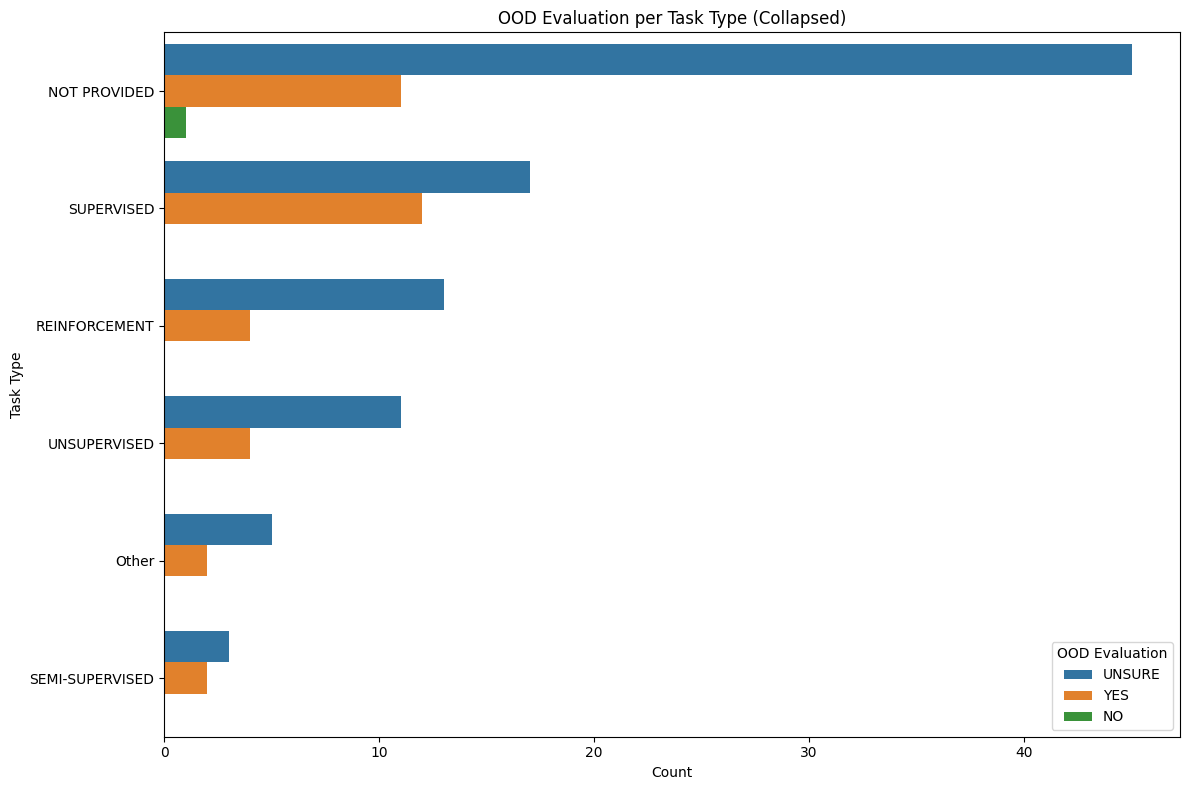

In [51]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Task Type",
    col_y="OOD Evaluation"
)

### Distribution of Architecture per Task Type

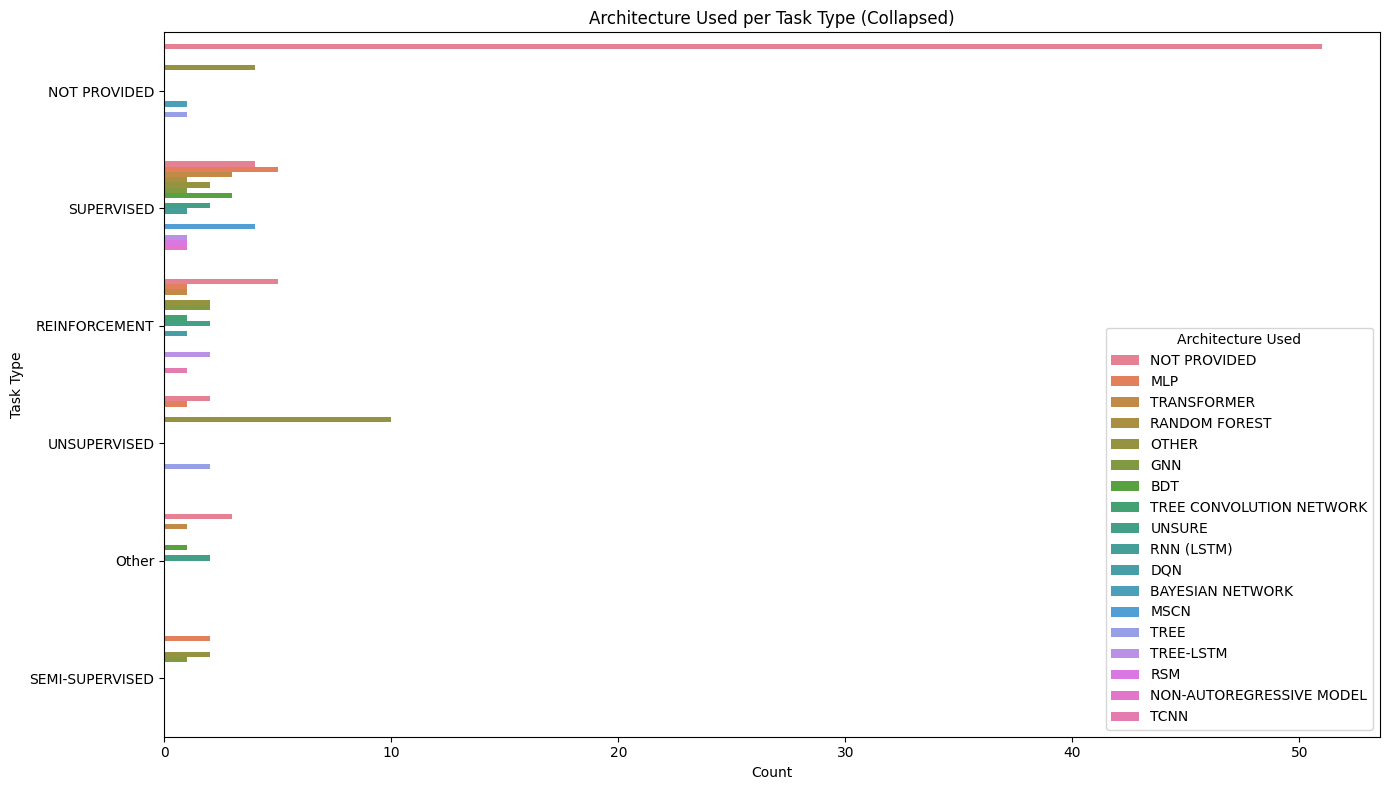

In [52]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Task Type",
    col_y="Architecture Used",
    min_count=5,
    figsize=(14, 8)
)

## Analysis on Learning Paradigm

### Distribution of Learning Paradigm Over Time

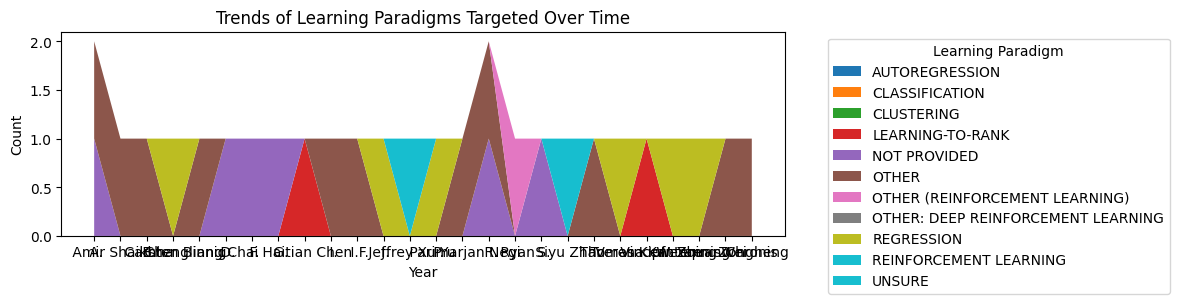

In [53]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Learning Paradigm_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Learning Paradigm_', '') if x.startswith('Learning Paradigm_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Learning Paradigms Targeted Over Time")
plt.legend(title="Learning Paradigm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Learning Paradigm Over all Papers

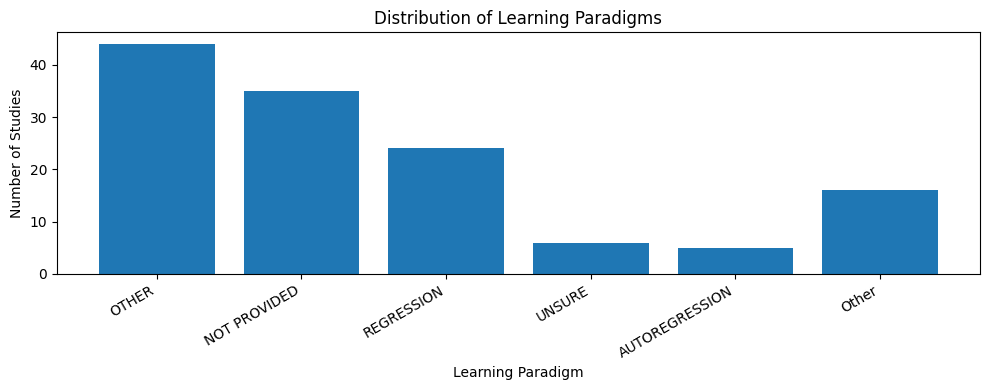

In [54]:
plot_multilabel_distribution(answers_df_encoded, "Learning Paradigm", "Distribution of Learning Paradigms")

### All Data Generation Methods per Machine Learning Paradigm

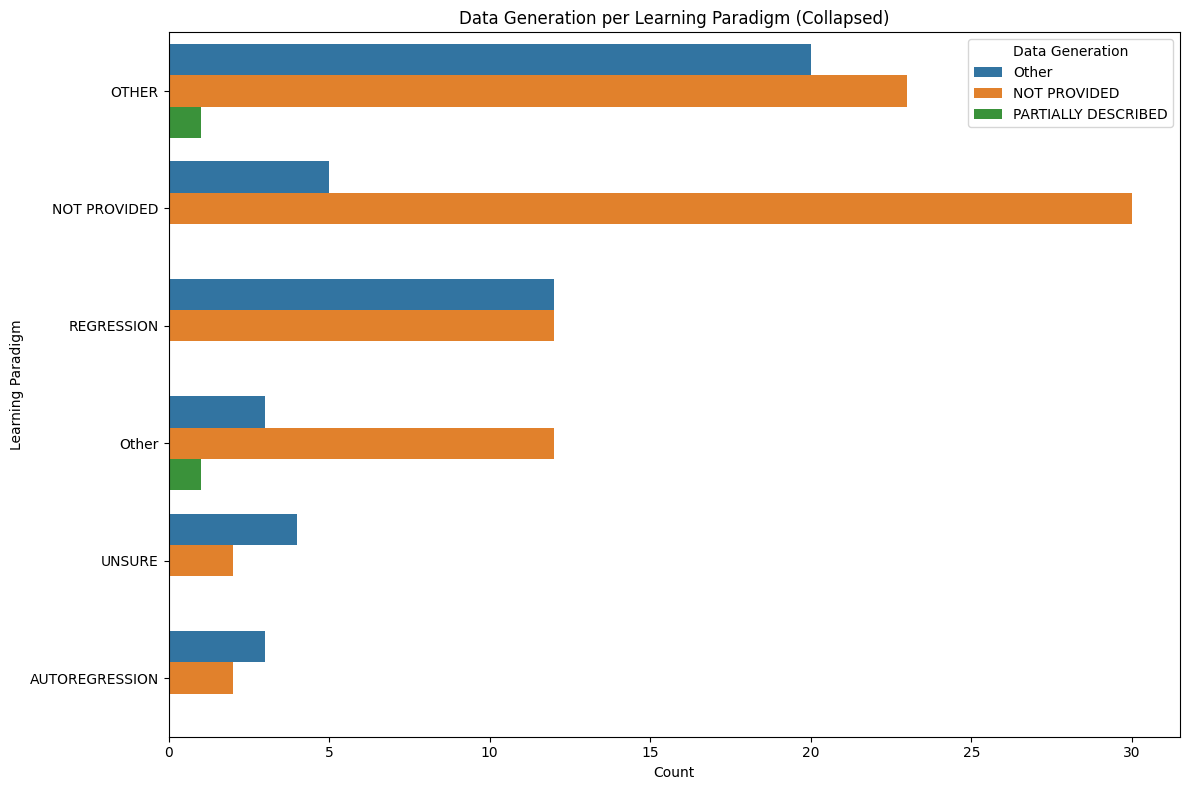

In [55]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Learning Paradigm",
    col_y="Data Generation"
)


### All Input Encoding Methods per Machine Learning Paradigm

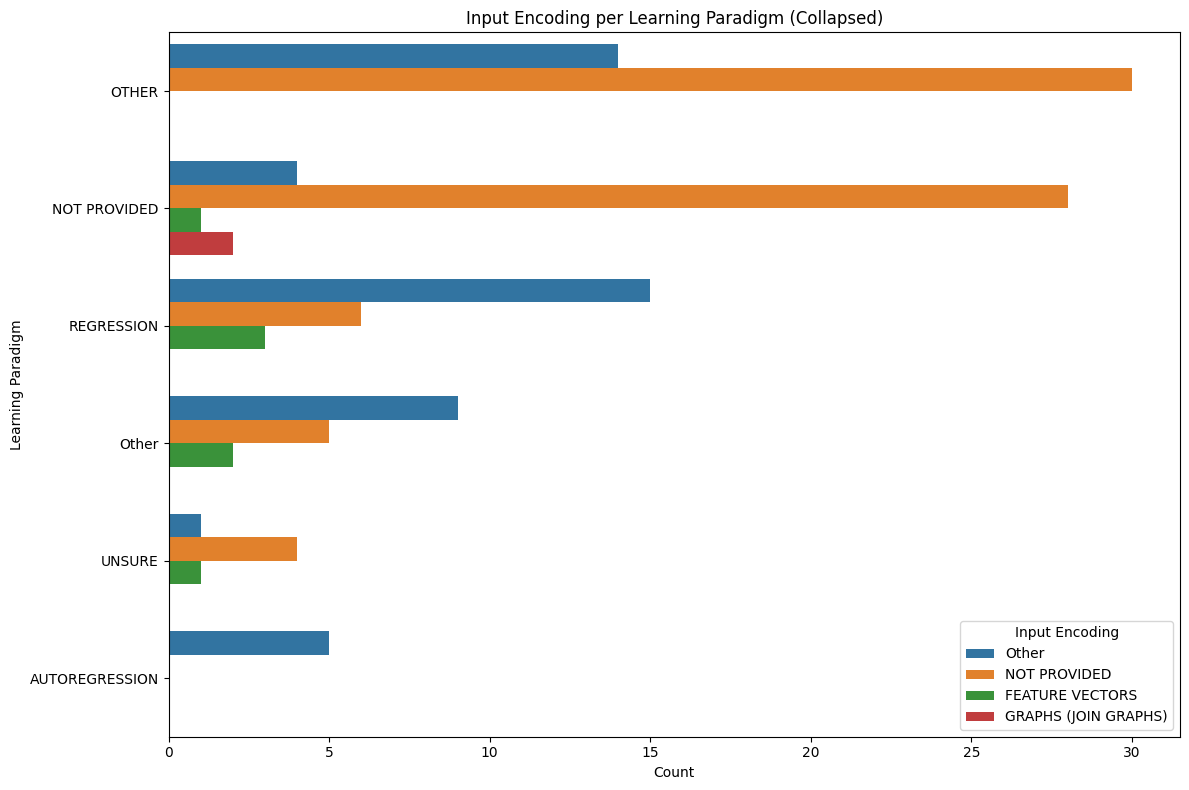

In [56]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Learning Paradigm",
    col_y="Input Encoding"
)


## Analysis on Training Data Generation

### Distribution of Training Data Generation Methods Over Time

In [57]:
! pip install squarify

In [72]:
# raw_answers = []
# for paper_id, content in responses.items():
#     ans = content.get('answers', {}).get('Q20', {}).get('ShortAnswer', 'Not provided')
#     raw_answers.append(ans)

# # Flatten lists and remove strict garbage
# garbage = ['0', '1', '0.0', '1.0', 'True', 'False', 'nan', 'None', '[]']
# all_methods = []
# for ans in raw_answers:
#     if isinstance(ans, list):
#         for item in ans:
#             if str(item).strip() not in garbage:
#                 all_methods.append(str(item).strip())
#     else:
#         if str(ans).strip() not in garbage:
#             all_methods.append(str(ans).strip())

# #  DEFINE CATEGORIES (The Meta-Analysis Logic)
# def categorize_method(text):
#     text = text.lower()

#     # Hierarchy of checks (order matters!)
#     if "not provided" in text or "not fully" in text or "partially" in text:
#         return "Not Specified / Partial"

#     if any(x in text for x in ["sample", "sampling"]):
#         return "Sampling-based"

#     if any(x in text for x in ["benchmark", "job", "tpc", "stats dataset", "wmt", "imdb"]):
#         return "Standard Benchmarks"

#     if any(x in text for x in ["log", "history", "runtime", "profile", "trace", "execution plans"]):
#         return "Workload Logs / Runtime"

#     if any(x in text for x in ["synthetic", "generate", "random", "template", "simulation", "simulated", "qgen", "zipf"]):
#         return "Synthetic / Random Generation"

#     return "Other Specific Methods"

# #  APPLY CATEGORIZATION
# df_methods = pd.DataFrame(all_methods, columns=['Original_Text'])
# df_methods['Category'] = df_methods['Original_Text'].apply(categorize_method)

# # Count the categories
# category_counts = df_methods['Category'].value_counts()

# print("--- Check the Categorization (First 10 examples) ---")
# print(df_methods.head(10))
# print("\n")

# # PLOT THE META-ANALYSIS
# plt.figure(figsize=(10, 6))

# colors = ['lightgrey' if 'Not Specified' in x else 'teal' for x in category_counts.index]

# sns.barplot(x=category_counts.values, y=category_counts.index, palette=colors)

# plt.title("Meta-Analysis: Distribution of Data Generation Approaches")
# plt.xlabel("Number of Studies")
# plt.ylabel("Approach Category")
# plt.grid(axis='x', linestyle='--', alpha=0.5)

# for i, v in enumerate(category_counts.values):
#     plt.text(v + 0.5, i, str(v), va='center')

# plt.tight_layout()
# plt.show()

In [ ]:
# target_cols = [col for col in answers_df_encoded.columns if col.startswith('Data Generation_')]

# time_series = answers_df_encoded[['Year'] + target_cols].copy()
# time_series = time_series.groupby(by='Year').sum()
# time_series.sort_values(by='Year', inplace=True)

# time_series.rename(
#     columns=lambda x: x.replace('Data Generation_', '') if x.startswith('Data Generation_') else x,
#     inplace=True
# )

# # Prepare the data for the stackplot
# years = time_series.index.values
# stack_data = [time_series[col].values for col in time_series.columns]

# # Generate a pastel color palette using the 'tab10' colormap
# cmap = plt.get_cmap("tab10")
# colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

# plt.figure(figsize=(12, 3))
# plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

# plt.xlabel("Year")
# plt.ylabel("Count")
# plt.title("Trends of Data Generation Methods Used Over Time")
# plt.legend(title="Data Generation Method", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

### Bar Plot of Training Data Generation Methods

In [65]:
# plot_multilabel_distribution(answers_df_encoded, "Data Generation", "Distribution of Data Generation Methods Used")

### Comparing Data Generation Methods per Input Encoding Method

In [67]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="Data Generation",
#     col_y="Input Encoding"
# )

### Data Generation Methods that have Uncertainty Evaluation

In [71]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="Data Generation",
#     col_y="Uncertainty Evaluation"
# )

### Data Generation Methods that have OOD Evaluation

In [ ]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="Data Generation",
#     col_y="OOD Evaluation"
# )

## Revised Version of each column

/tmp/ipython-input-1762262062.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_gen.values, y=counts_gen.index, palette=colors_gen)


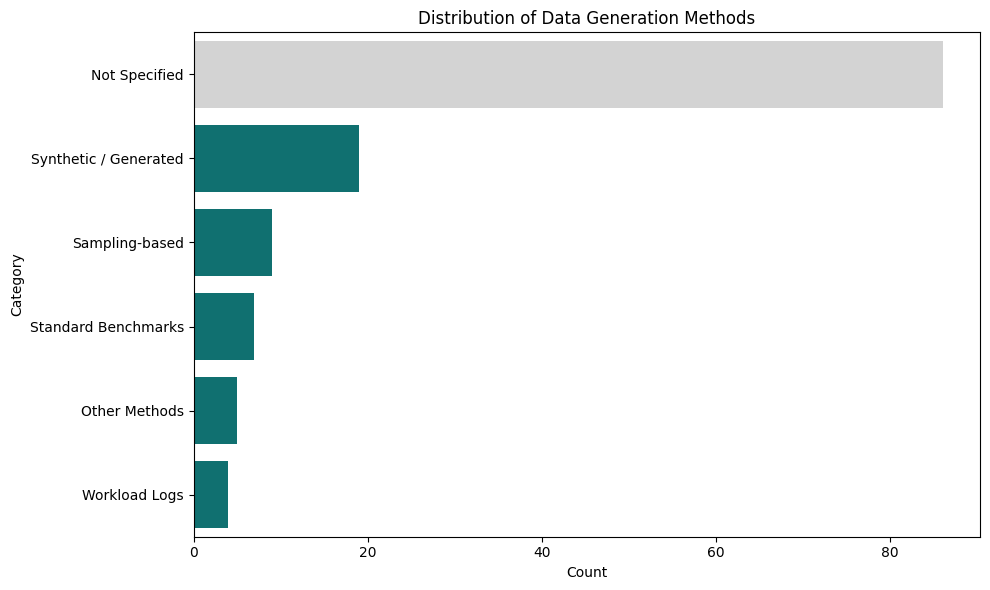

/tmp/ipython-input-1762262062.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_enc.values, y=counts_enc.index, palette=colors_enc)


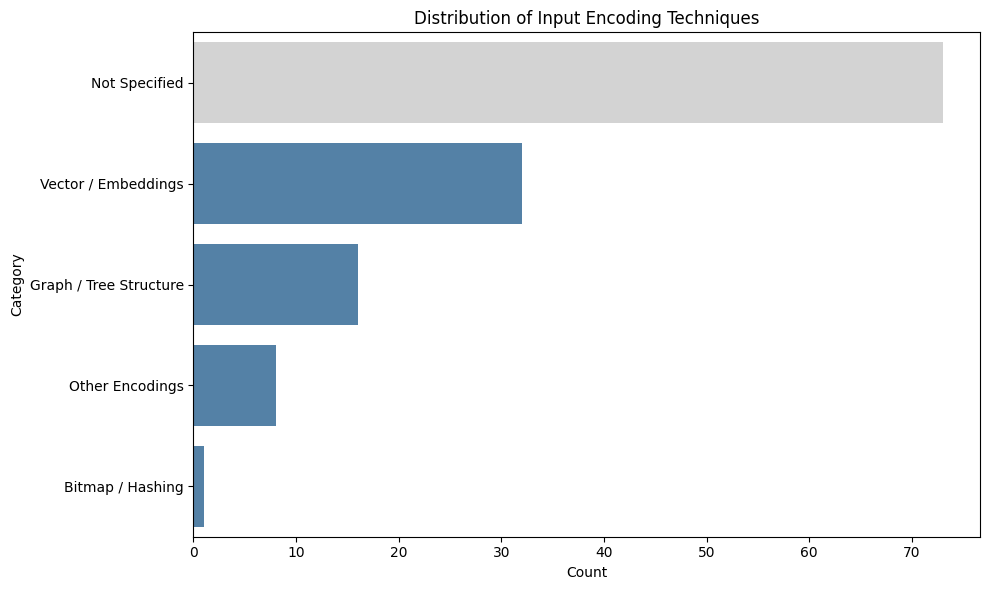

/tmp/ipython-input-1762262062.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_unc.index, y=counts_unc.values, palette=colors_unc)


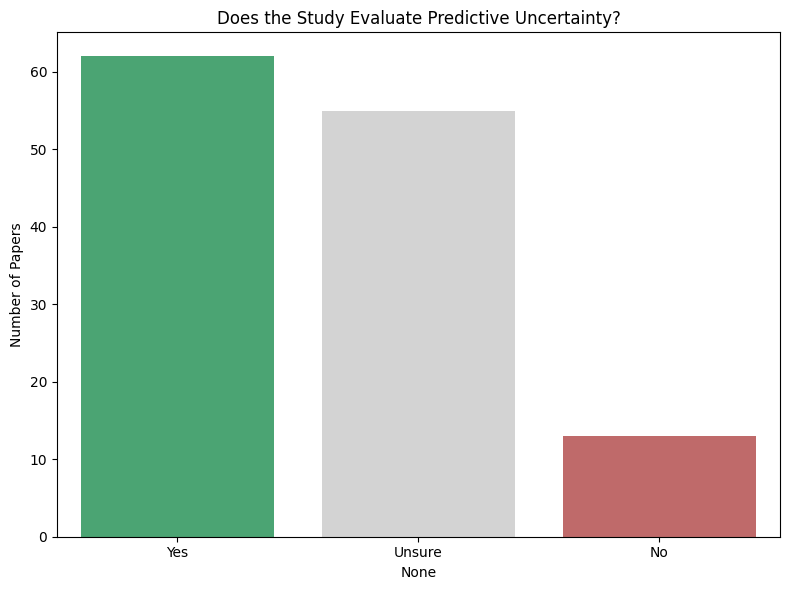

/tmp/ipython-input-1762262062.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_ood.index, y=counts_ood.values, palette=colors_ood)


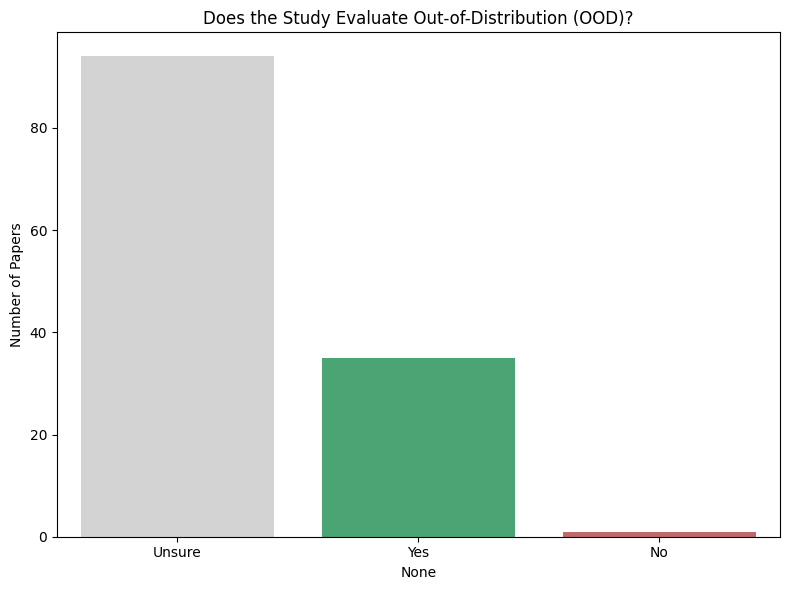

In [73]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Helper to extract and clean specific questions
def get_clean_data(q_id):
    raw_list = []
    for pid, content in responses.items():
        ans = content.get('answers', {}).get(q_id, {}).get('ShortAnswer', 'Not provided')
        if isinstance(ans, list):
            for x in ans: raw_list.append(str(x).strip())
        else:
            raw_list.append(str(ans).strip())

    # Basic Cleaning
    garbage = ['0', '1', 'nan', 'None', '[]']
    return [x for x in raw_list if x not in garbage]


def categorize_data_gen(text):
    t = text.lower()
    if "not provided" in t or "partially" in t: return "Not Specified"
    if "sample" in t or "sampling" in t: return "Sampling-based"
    if any(x in t for x in ["benchmark", "job", "tpc", "stats", "wmt"]): return "Standard Benchmarks"
    if any(x in t for x in ["log", "history", "runtime", "trace"]): return "Workload Logs"
    if any(x in t for x in ["synthetic", "generate", "random", "simulat"]): return "Synthetic / Generated"
    return "Other Methods"

def categorize_encoding(text):
    t = text.lower()
    if "not provided" in t: return "Not Specified"
    if any(x in t for x in ["vector", "embedding", "numerical", "feature"]): return "Vector / Embeddings"
    if any(x in t for x in ["graph", "tree", "plan", "structure"]): return "Graph / Tree Structure"
    if any(x in t for x in ["bit", "binary", "hash", "one-hot"]): return "Bitmap / Hashing"
    return "Other Encodings"


# 1. DISTRIBUTION OF DATA GENERATION METHODS
raw_gen = get_clean_data("Q20")
df_gen = pd.DataFrame(raw_gen, columns=['Text'])
df_gen['Category'] = df_gen['Text'].apply(categorize_data_gen)
counts_gen = df_gen['Category'].value_counts()

plt.figure(figsize=(10, 6))
colors_gen = ['lightgrey' if 'Not' in x else 'teal' for x in counts_gen.index]
sns.barplot(x=counts_gen.values, y=counts_gen.index, palette=colors_gen)
plt.title("Distribution of Data Generation Methods")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# 2. DISTRIBUTION OF INPUT ENCODING
raw_enc = get_clean_data("Q21")
df_enc = pd.DataFrame(raw_enc, columns=['Text'])
df_enc['Category'] = df_enc['Text'].apply(categorize_encoding)
counts_enc = df_enc['Category'].value_counts()

plt.figure(figsize=(10, 6))
colors_enc = ['lightgrey' if 'Not' in x else 'steelblue' for x in counts_enc.index]
sns.barplot(x=counts_enc.values, y=counts_enc.index, palette=colors_enc)
plt.title("Distribution of Input Encoding Techniques")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# 3. UNCERTAINTY EVALUATION (Q22)
# These are typically Yes/No/Unsure
raw_unc = get_clean_data("Q22")
counts_unc = pd.Series(raw_unc).value_counts()

plt.figure(figsize=(8, 6))
# Custom color map for Yes/No/Unsure
color_map = {'Yes': 'mediumseagreen', 'No': 'indianred', 'Unsure': 'lightgrey', 'Not provided': 'lightgrey'}
colors_unc = [color_map.get(x, 'grey') for x in counts_unc.index]
sns.barplot(x=counts_unc.index, y=counts_unc.values, palette=colors_unc)
plt.title("Does the Study Evaluate Predictive Uncertainty?")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()

#  OOD EVALUATION (Q24)
raw_ood = get_clean_data("Q24")
counts_ood = pd.Series(raw_ood).value_counts()

plt.figure(figsize=(8, 6))
colors_ood = [color_map.get(x, 'grey') for x in counts_ood.index]
sns.barplot(x=counts_ood.index, y=counts_ood.values, palette=colors_ood)
plt.title("Does the Study Evaluate Out-of-Distribution (OOD)?")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()

## Analysis on Input Encoding

### Distribution of Task Type Over all Papers

/tmp/ipython-input-676684790.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_methods.values, y=top_methods.index, palette="viridis")
/tmp/ipython-input-676684790.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


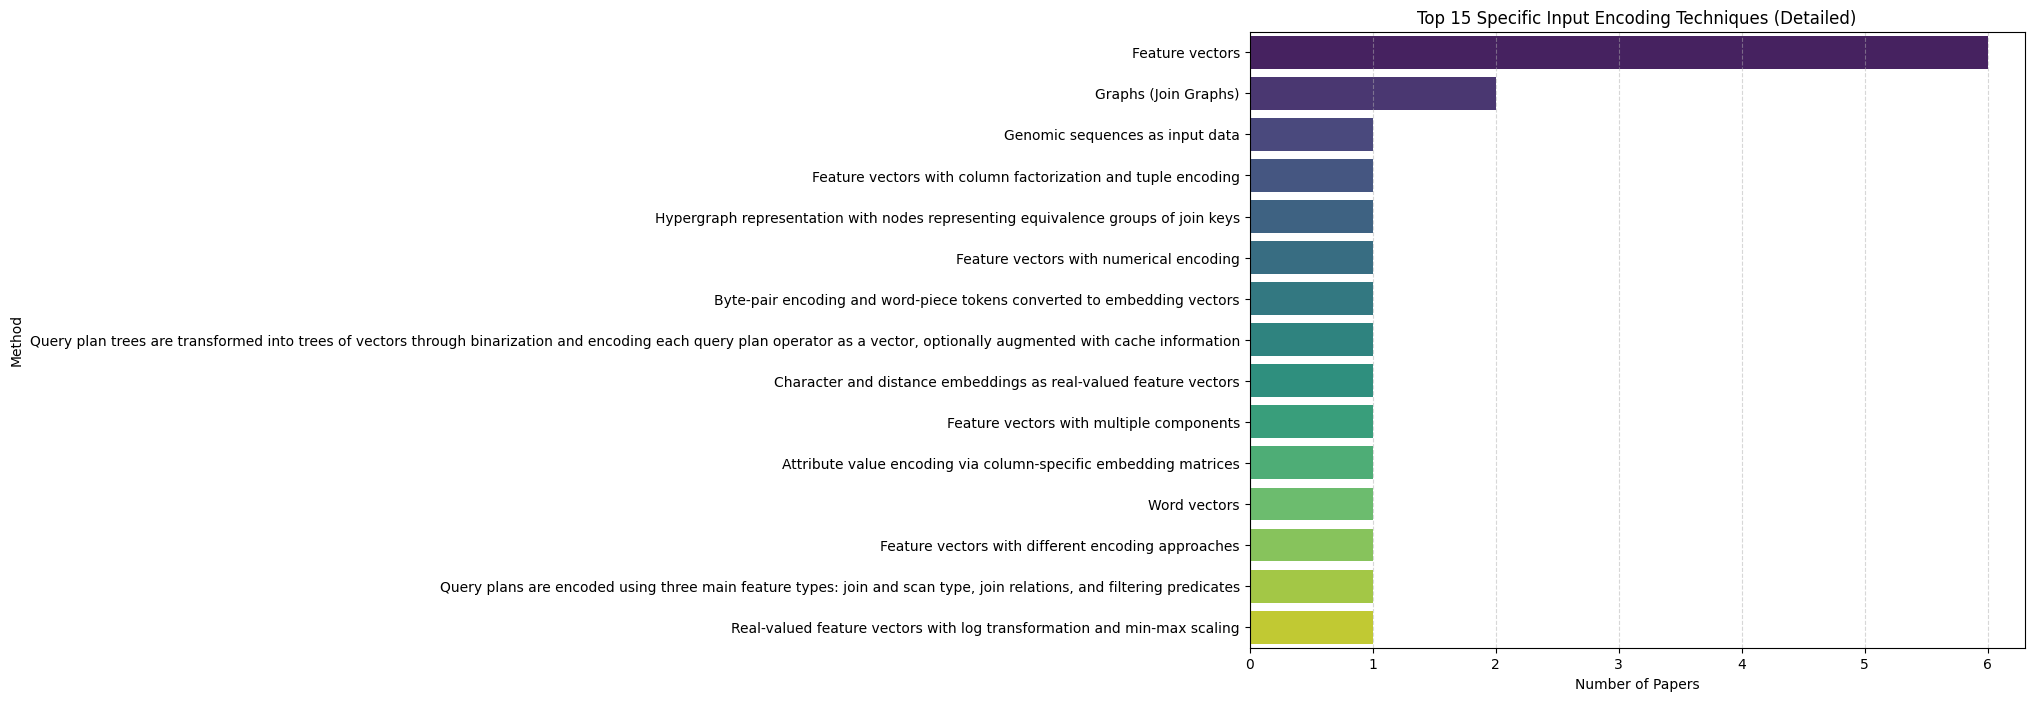

In [76]:
raw_answers = []
for pid, content in responses.items():
    ans = content.get('answers', {}).get('Q21', {}).get('ShortAnswer', 'Not provided')
    if isinstance(ans, list):
        for x in ans: raw_answers.append(str(x).strip())
    else:
        raw_answers.append(str(ans).strip())

# 2. FILTER GARBAGE & "NOT PROVIDED"
# We remove generic answers to see the meaningful specific ones
ignore_list = [
    '0', '1', 'nan', 'None', '[]', 'Not provided', 'Partially described',
    'Yes', 'No', 'Unsure'
]

clean_answers = [x for x in raw_answers if x not in ignore_list and len(x) > 3]

# 3. COUNT AND SELECT TOP 15
df_enc = pd.DataFrame(clean_answers, columns=['Method'])
top_methods = df_enc['Method'].value_counts().head(15)

# 4. PLOT DETAILED VIEW
plt.figure(figsize=(10, 8))
sns.barplot(x=top_methods.values, y=top_methods.index, palette="viridis")

plt.title("Top 15 Specific Input Encoding Techniques (Detailed)")
plt.xlabel("Number of Papers")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

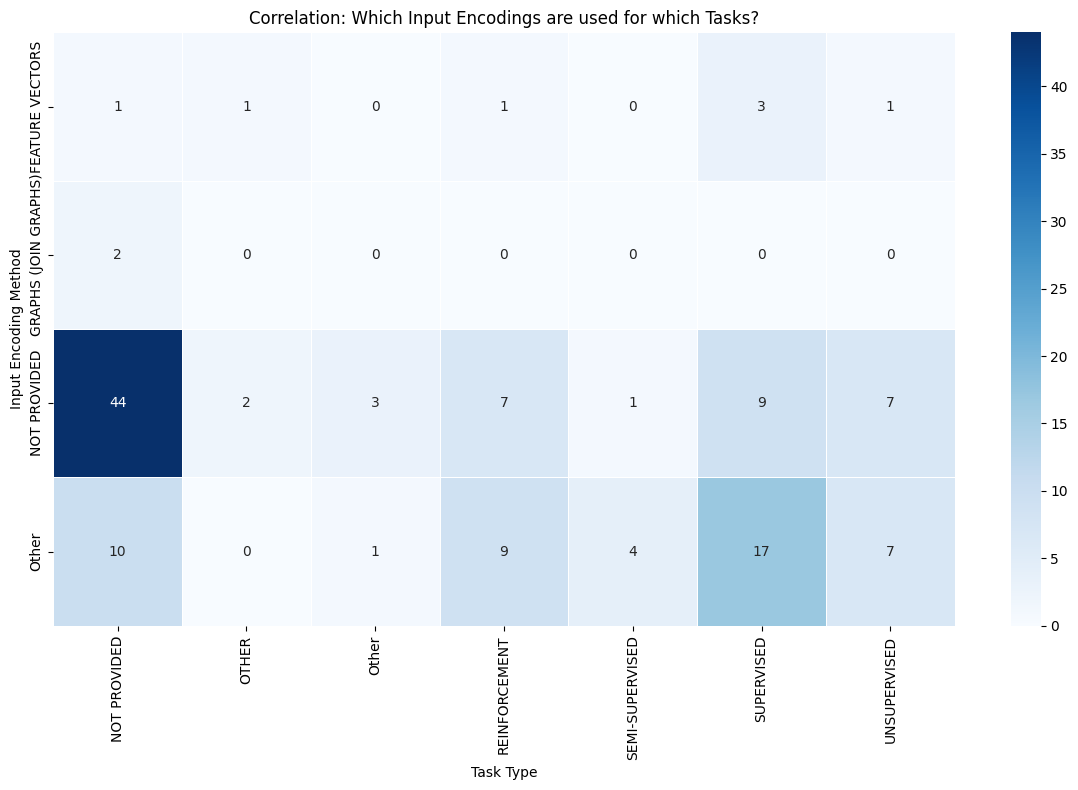

In [78]:
def prepare_heatmap_data(df, col_x, col_y, min_count=2):
    # Filter garbage
    garbage = ['0', '1', 'nan', 'None', '[]', 'Not provided']

    # Helper to clean list/string
    def cleaner(val):
        if isinstance(val, list):
            return [x for x in val if str(x).strip() not in garbage]
        return [str(val).strip()] if str(val).strip() not in garbage else []

    # Clean both columns
    s_x = df[col_x].apply(cleaner).explode()
    s_y = df[col_y].apply(cleaner).explode()

    # Create a clean DataFrame
    df_clean = pd.DataFrame({col_x: s_x, col_y: s_y}).dropna()

    # Filter rare items (to keep heatmap readable)
    top_x = df_clean[col_x].value_counts()
    top_y = df_clean[col_y].value_counts()

    valid_x = top_x[top_x >= min_count].index
    valid_y = top_y[top_y >= min_count].index

    df_final = df_clean[df_clean[col_x].isin(valid_x) & df_clean[col_y].isin(valid_y)]

    return pd.crosstab(df_final[col_y], df_final[col_x])

# GENERATE HEATMAP
heatmap_data = prepare_heatmap_data(answers_df, "Task Type", "Input Encoding", min_count=2)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap="Blues", linewidths=.5)

plt.title("Correlation: Which Input Encodings are used for which Tasks?")
plt.xlabel("Task Type")
plt.ylabel("Input Encoding Method")
plt.tight_layout()
plt.show()

### Distribution of Task Type Over all Papers Over Time

In [79]:
# plot_multilabel_distribution(answers_df_encoded, "Input Encoding", "Distribution of Input Encoding Methods")

### Uncertainty Evaluation Counts per Input Encoding

In [80]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="Input Encoding",
#     col_y="Uncertainty Evaluation"
# )

### Out of Distribution Evaluation Counts per Input Encoding

In [81]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="Input Encoding",
#     col_y="OOD Evaluation"
# )

### Input Encoding Methods used per Model Architecture

In [82]:
# plot_multilabel_relation_explode(
#     df=answers_df,
#     col_x="Input Encoding",
#     col_y="Architecture Used"
# )

/tmp/ipython-input-2445721147.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_enc.values, y=counts_enc.index, palette=colors_enc)


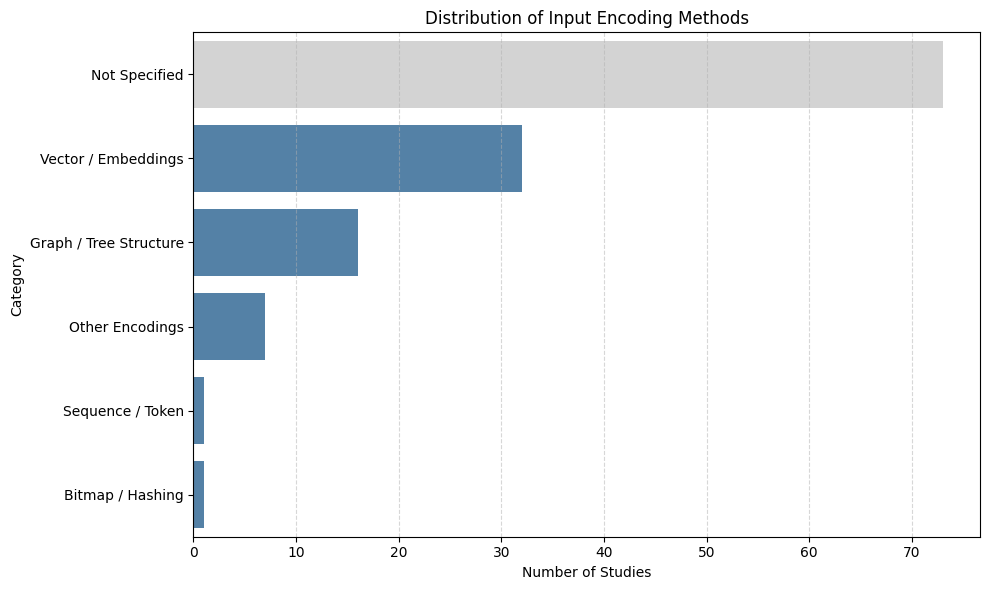

/tmp/ipython-input-2445721147.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_arch.values, y=counts_arch.index, palette=colors_arch)


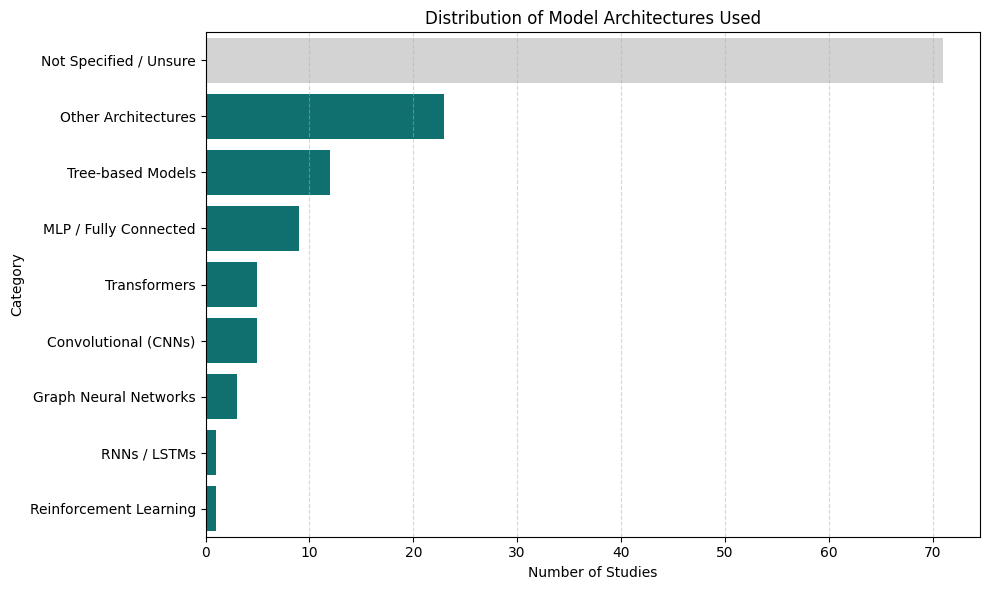

/tmp/ipython-input-2445721147.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_unc.index, y=counts_unc.values, palette=[color_map.get(x, 'grey') for x in counts_unc.index])


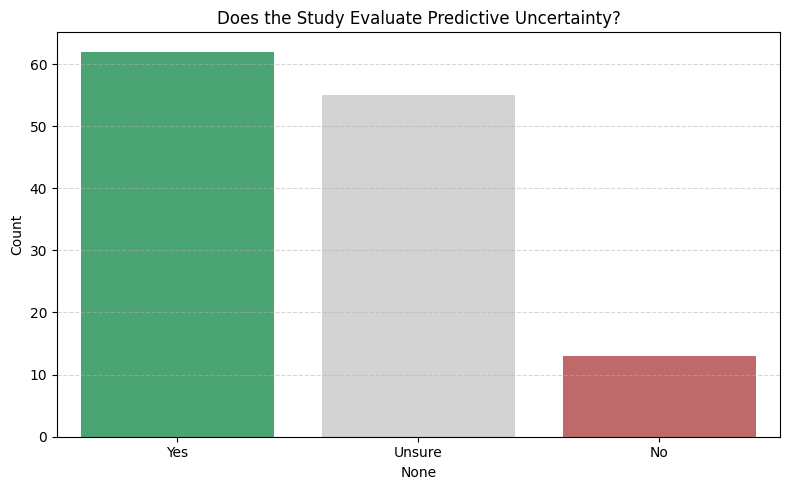

/tmp/ipython-input-2445721147.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_ood.index, y=counts_ood.values, palette=[color_map.get(x, 'grey') for x in counts_ood.index])


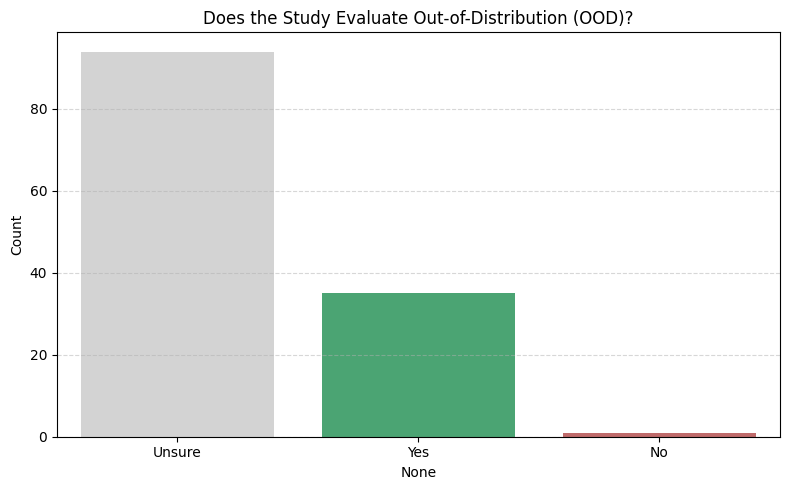

In [83]:
def get_clean_data(q_id, garbage_list=['0', '1', 'nan', 'None', '[]']):
    raw_list = []
    for pid, content in responses.items():
        ans = content.get('answers', {}).get(q_id, {}).get('ShortAnswer', 'Not provided')
        # Handle lists vs strings
        if isinstance(ans, list):
            for x in ans: raw_list.append(str(x).strip())
        else:
            raw_list.append(str(ans).strip())

    # Remove garbage
    return [x for x in raw_list if x not in garbage_list]

# --- CATEGORIZATION LOGIC ---

def categorize_encoding(text):
    t = text.lower()
    if "not provided" in t or "partially" in t: return "Not Specified"
    if any(x in t for x in ["vector", "embedding", "numeric", "feature", "one-hot"]): return "Vector / Embeddings"
    if any(x in t for x in ["graph", "tree", "plan", "structure", "node"]): return "Graph / Tree Structure"
    if any(x in t for x in ["bit", "binary", "hash", "sketch"]): return "Bitmap / Hashing"
    if any(x in t for x in ["sequence", "token", "string"]): return "Sequence / Token"
    return "Other Encodings"

def categorize_architecture(text):
    t = text.lower()
    if "not provided" in t or "unsure" in t: return "Not Specified / Unsure"
    if any(x in t for x in ["mlp", "feedforward", "fully connected", "fcn"]): return "MLP / Fully Connected"
    if any(x in t for x in ["tree", "forest", "bdt", "xgboost", "gbm", "decision"]): return "Tree-based Models"
    if any(x in t for x in ["transformer", "bert", "attention"]): return "Transformers"
    if any(x in t for x in ["gnn", "graph", "gcn", "gat"]): return "Graph Neural Networks"
    if any(x in t for x in ["rnn", "lstm", "gru", "recurrent"]): return "RNNs / LSTMs"
    if any(x in t for x in ["cnn", "convolution", "mscn", "tcnn"]): return "Convolutional (CNNs)"
    if any(x in t for x in ["dqn", "rl", "reinforcement"]): return "Reinforcement Learning"
    return "Other Architectures"

# --- GENERATE PLOTS ---

# 1. INPUT ENCODING (Q21)
raw_enc = get_clean_data("Q21")
df_enc = pd.DataFrame(raw_enc, columns=['Text'])
df_enc['Category'] = df_enc['Text'].apply(categorize_encoding)
counts_enc = df_enc['Category'].value_counts()

plt.figure(figsize=(10, 6))
colors_enc = ['lightgrey' if 'Not' in x else 'steelblue' for x in counts_enc.index]
sns.barplot(x=counts_enc.values, y=counts_enc.index, palette=colors_enc)
plt.title("Distribution of Input Encoding Methods")
plt.xlabel("Number of Studies")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. ARCHITECTURE USED (Q25)
raw_arch = get_clean_data("Q25")
df_arch = pd.DataFrame(raw_arch, columns=['Text'])
df_arch['Category'] = df_arch['Text'].apply(categorize_architecture)
counts_arch = df_arch['Category'].value_counts()

plt.figure(figsize=(10, 6))
colors_arch = ['lightgrey' if 'Not' in x else 'teal' for x in counts_arch.index]
sns.barplot(x=counts_arch.values, y=counts_arch.index, palette=colors_arch)
plt.title("Distribution of Model Architectures Used")
plt.xlabel("Number of Studies")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. UNCERTAINTY EVALUATION (Q22)
raw_unc = get_clean_data("Q22")
counts_unc = pd.Series(raw_unc).value_counts()
color_map = {'Yes': 'mediumseagreen', 'No': 'indianred', 'Unsure': 'lightgrey'}

plt.figure(figsize=(8, 5))
sns.barplot(x=counts_unc.index, y=counts_unc.values, palette=[color_map.get(x, 'grey') for x in counts_unc.index])
plt.title("Does the Study Evaluate Predictive Uncertainty?")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. OOD EVALUATION (Q24)
raw_ood = get_clean_data("Q24")
counts_ood = pd.Series(raw_ood).value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=counts_ood.index, y=counts_ood.values, palette=[color_map.get(x, 'grey') for x in counts_ood.index])
plt.title("Does the Study Evaluate Out-of-Distribution (OOD)?")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Analysis on Uncertainty Evaluation

### Bar Plot of papers that have Uncertainty Evaluations

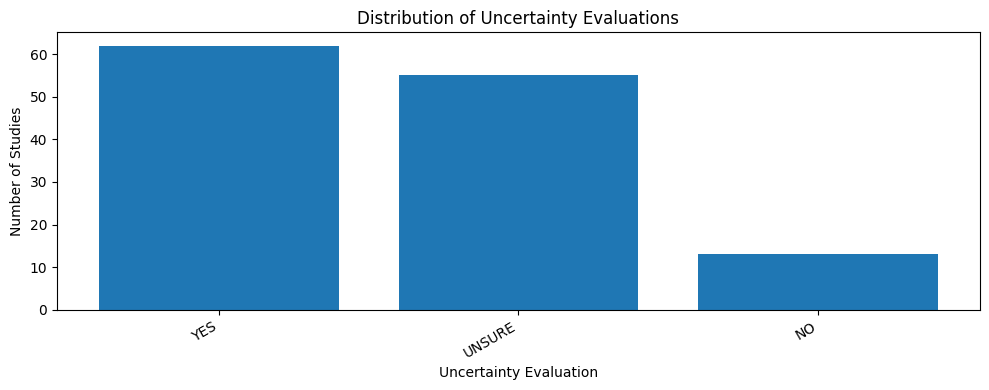

In [84]:
plot_multilabel_distribution(answers_df_encoded, "Uncertainty Evaluation", "Distribution of Uncertainty Evaluations")

### Uncertainty Evaluations that also account Out of Distribution Evaluations

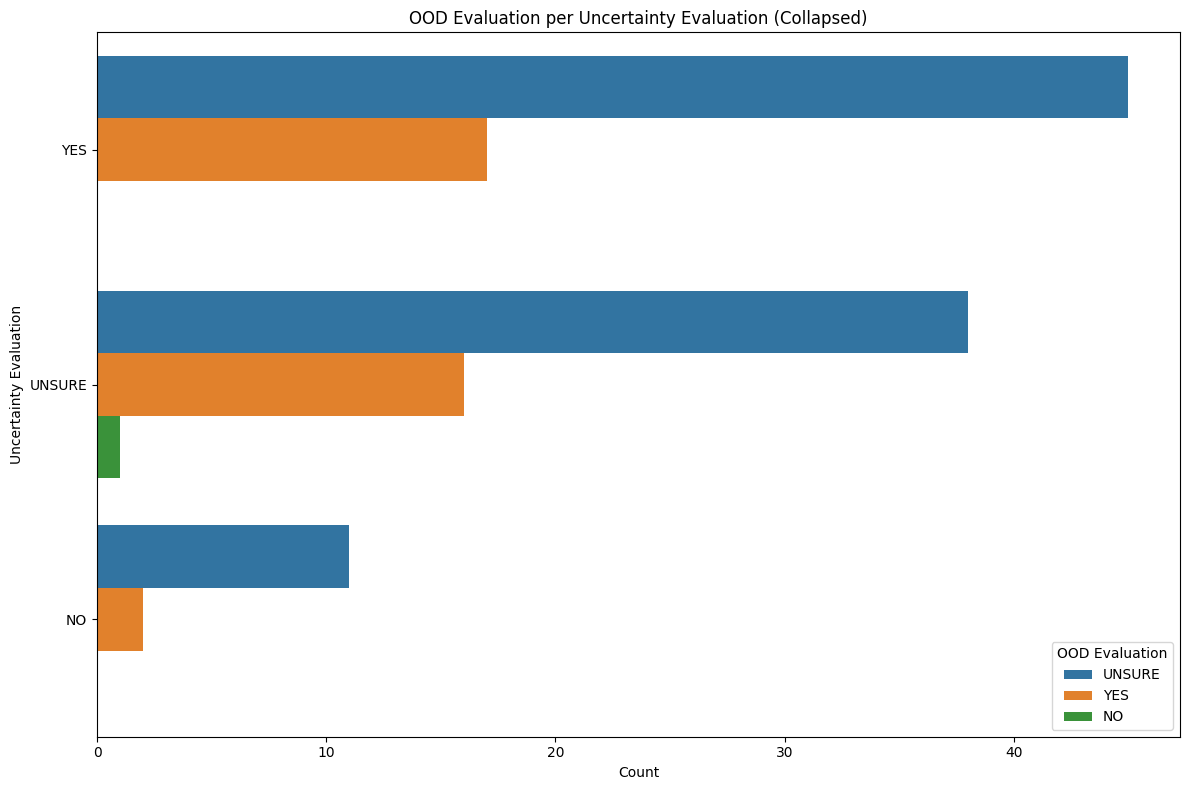

In [85]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Uncertainty Evaluation",
    col_y="OOD Evaluation"
)

### Uncertainty Evaluation Counts per Model Architecture

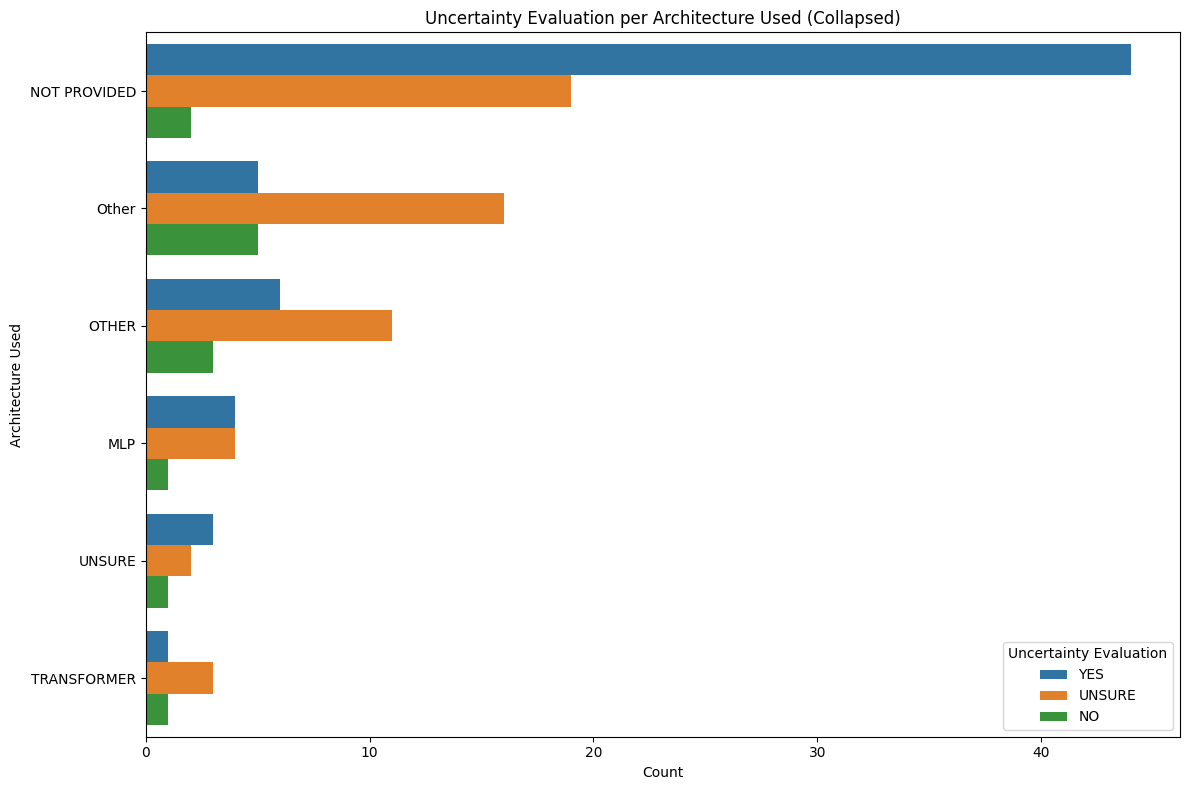

In [86]:
plot_multilabel_relation_explode(
    df=answers_df,
    col_x="Architecture Used",
    col_y="Uncertainty Evaluation"
)

## Analysis on Out of Distribution Evaluation

### Bar Plot of Training Data Generation Methods

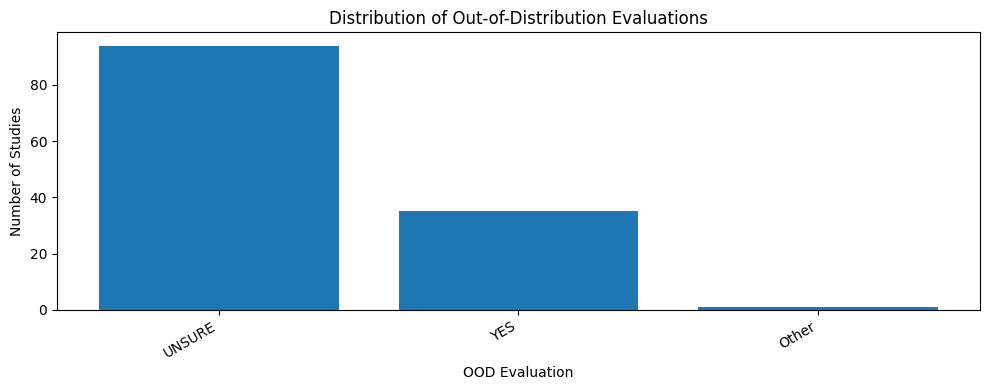

In [87]:
plot_multilabel_distribution(answers_df_encoded, "OOD Evaluation", "Distribution of Out-of-Distribution Evaluations")

## Analysis on Model Architecture

### Distribution of Model Architectures Used Over Time

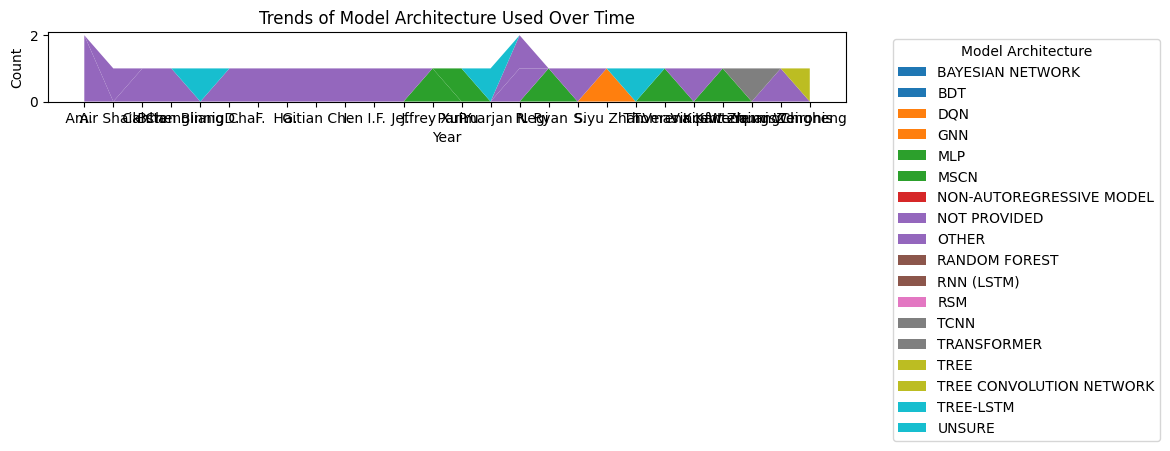

In [88]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Architecture Used_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Architecture Used_', '') if x.startswith('Architecture Used_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Model Architecture Used Over Time")
plt.legend(title="Model Architecture", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Model Architectures Used

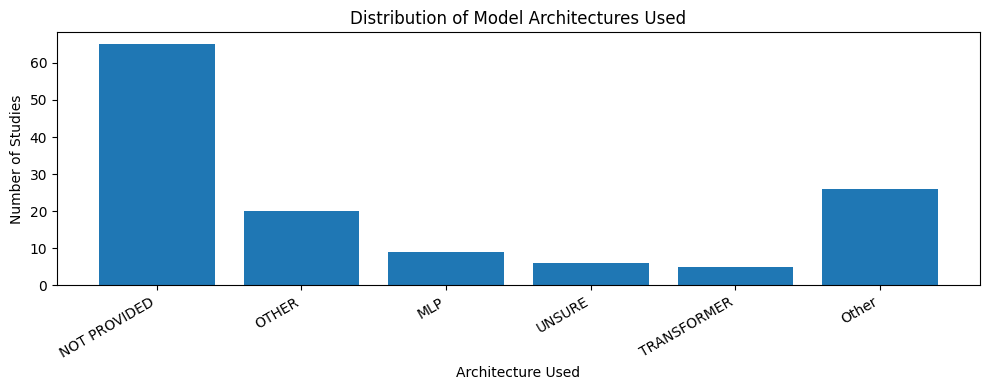

In [89]:
plot_multilabel_distribution(answers_df_encoded, "Architecture Used", "Distribution of Model Architectures Used")